**######### GPU ou CPU #########**

In [1]:
# Habilitar o Crescimento Dinâmico de Memória

import tensorflow as tf

# Habilita o crescimento de memória
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
  try:
    # Permite que a memória seja alocada incrementalmente
    for gpu in gpus:
      tf.config.experimental.set_memory_growth(gpu, True)
      
    print("Crescimento de memória da GPU habilitado.")
  except RuntimeError as e:
    print(f"Erro ao configurar o crescimento de memória: {e}")

Crescimento de memória da GPU habilitado.


In [ ]:
# Forçar o Uso da CPU

# Adicione esta linha antes de chamar o DeepFace
# import os
# os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

**### Parte 1 - Organizar Dataset ###**

**Carregar imagens do dataset**

In [2]:
import numpy as np
import os

from PIL import Image, ImageOps
from os import listdir
from os.path import isdir, join


## Carregar Dataset
def carregar_dataset(directory):
  """
  Carrega imagens de um diretório, onde cada subdiretório representa uma classe.

  Args:
    directory (str): O caminho para o diretório raiz do dataset.

  Returns:
    tuple: Duas listas: (list of image arrays, list of labels)
  """
  all_images = list()
  all_labels = list()
  all_paths = list()

  # Enumerar as pastas, uma por classe
  for subdir in listdir(directory):
    path = join(directory, subdir)

    # Ignorar qualquer arquivo que esteja no diretório raiz
    if not isdir(path):
      continue

    # Carregar as imagens que estão nos subdiretórios
    current_subdir_images = list()
    current_subdir_paths = list()
    for filename in listdir(path):
      image_path = join(path, filename)

      try:
        # Carrega a imagem e converte para array NumPy
        image = Image.open(image_path).convert('RGB') 
        # Apply EXIF-based rotation/flip
        image = ImageOps.exif_transpose(image)
        image_array = np.array(image)
        current_subdir_images.append(image_array)
        current_subdir_paths.append(image_path)

      except Exception as e:
        print(f"Erro ao carregar a imagem {image_path}: {e}")
        continue # Pule para a próxima imagem se ocorrer algum erro

    # Adicionar as imagens e rótulos ao dataset geral
    if current_subdir_images:
      num_images_in_subdir = len(current_subdir_images)
      labels_for_subdir = [subdir for _ in range(num_images_in_subdir)]

      all_images.extend(current_subdir_images)
      all_labels.extend(labels_for_subdir)
      all_paths.extend(current_subdir_paths)
        
      #print(f'> Carregadas {num_images_in_subdir} imagens para a classe: {subdir}')
    else:
      print(f'>> Nenhuma imagem carregada para a classe: {subdir}')

  return all_images, all_labels, all_paths

**Ordenar Dataset**

In [3]:
import os

def ordenar_dataset(db_images, db_labels, db_images_path):
    """
    Ordena as listas de embeddings, rótulos e caminhos de forma consistente, 
    agrupando imagens da mesma classe (identidade) de forma subsequente.
    
    Args:
        db_images (list): Lista de embeddings (imagens).
        db_labels (list): Lista de rótulos (identidades/classes).
        db_images_path (list): Lista de caminhos de arquivos de imagem.
        
    Returns:
        tuple: (list(sorted_images), list(sorted_labels), list(sorted_paths))
    """
    # 1. Combina as listas em uma lista de tuplas para ordenação
    combined = list(zip(db_images_path, db_images, db_labels))
    
    # 2. Define a chave de ordenação
    # A chave deve ser uma tupla: (Identidade/Classe, Nome do Arquivo)
    def get_sorting_key(item):
        path = item[0] # O caminho do arquivo é o primeiro elemento da tupla combinada
        
        # Identidade/Classe: Nome do diretório pai (para agrupamento)
        identity = os.path.basename(os.path.dirname(path))
        
        # Nome do Arquivo: Nome base do arquivo (para ordenação secundária)
        filename = os.path.basename(path)
        
        return (identity, filename)
    
    # 3. Ordena a lista combinada usando a chave composta
    # O Python ordenará pela identidade primeiro, agrupando as classes.
    combined.sort(key=get_sorting_key)
    
    # 4. Desempacota as listas ordenadas
    # x[0]=Path, x[1]=Image/Embedding, x[2]=Label
    sorted_paths, sorted_images, sorted_labels = zip(*combined)
    
    # 5. Retorna as listas ordenadas
    return list(sorted_images), list(sorted_labels), list(sorted_paths)

**Carregamento e ordenação do dataset**

In [4]:
# Carrega o dataset e ordena para fins de reprodutibilidade.
dataset_directory = 'FFC-Dataset-10k'

print(f"1. Iniciando o carregamento do dataset em: {dataset_directory}")

# Chama a função externa carregar_dataset
db_images, db_labels, db_images_path = carregar_dataset(dataset_directory)

# Ordena o dataset carregado
print(f"2. Ordenando {len(db_images)} imagens para reprodutibilidade...")
db_images, db_labels, db_images_path = ordenar_dataset(
    db_images, db_labels, db_images_path
)

print(f"Total de imagens carregadas: {len(db_images)}")
print(f"Total de rótulos carregados: {len(db_labels)}")
print("-" * 30)


1. Iniciando o carregamento do dataset em: FFC-Dataset-10k
2. Ordenando 10000 imagens para reprodutibilidade...
Total de imagens carregadas: 10000
Total de rótulos carregados: 10000
------------------------------


**### Parte 2 - Deepface Framework ###**

**Função para redimensionar imagem**


In [5]:
import cv2

# Pre-processamento

# Dimensão máxima para pré-redimensionamento
MAX_DIMENSION = 640

# --- Função Auxiliar: Redimensiona na Memória ---
def resize_image_in_memory(img_array: np.ndarray) -> tuple[np.ndarray, float]:
    """
    Redimensiona a imagem (NumPy array) na memória para MAX_DIMENSION (640).
    Isso acelera a detecção pelo DeepFace.
    """
    h, w = img_array.shape[:2]
    scale_factor = MAX_DIMENSION / max(h, w)
    new_w = int(w * scale_factor)
    new_h = int(h * scale_factor)
    # Use INTER_AREA para redução de tamanho (melhor qualidade)
    resized_img = cv2.resize(img_array, (new_w, new_h), interpolation=cv2.INTER_AREA)
    return resized_img, scale_factor

**Modelos (geradores de embeddings) e backends (detectores de face) do deepface**

In [6]:
# Importar o Deepface
from deepface import DeepFace

models = [
    "VGG-Face", "Facenet", "Facenet512", "OpenFace", "DeepFace",
    "DeepID", "ArcFace", "Dlib", "SFace", "GhostFaceNet",
    "Buffalo_L",
]

backends = [
    'opencv', 'ssd', 'dlib', 'mtcnn', 'fastmtcnn',
    'retinaface', 'mediapipe', 'yolov8', 'yolov11s',
    'yolov11n', 'yolov11m', 'yunet', 'centerface',
]

**Gera embedding para cada imagem do dataset**

In [7]:
def gerar_embeddings_dataset(db_images, db_labels, db_images_path, model, backend, verbose=True):
    """
    Calcula e armazena os embeddings faciais para um conjunto de imagens usando o DeepFace.

    Args:
        db_images (list): Lista de imagens (dados de imagem).
        db_labels (list): Lista de rótulos (classes) correspondentes.
        db_images_path (list): Lista de caminhos de arquivo correspondentes (usados como chave no dicionário).
        models (str): Modelo de geração de embeddings.
        backend (str): Modelo de detecção de face.
        verbose (bool): Se True, imprime mensagens de sucesso e falha.

    Returns:
        dict: Um dicionário onde a chave é o caminho da imagem e o valor é uma lista 
              dos embeddings detectados (ou uma lista vazia em caso de falha).
    """
    
    face_embeddings_by_image = {}

    for i, img in enumerate(db_images):
        current_label = db_labels[i]
        current_image_path = db_images_path[i]

        try:
            # Assumindo que resize_image_in_memory e DeepFace estão disponíveis no escopo
            img, _ = resize_image_in_memory(img)
            
            detected_faces = DeepFace.represent(img_path=img,
                                                 model_name=model,
                                                 detector_backend=backend,
                                                 align=True,
                                                 enforce_detection=True
                                                )
            
            # Se múltiplas faces foram detectadas, selecionar a de maior área
            if len(detected_faces) > 1:
                # Calcular a área de cada face detectada
                face_with_max_area = max(detected_faces, key=lambda face: 
                    face['facial_area']['w'] * face['facial_area']['h']
                )
                detected_faces = [face_with_max_area]
                
                if verbose:
                    print(f"Múltiplas faces detectadas ({len(detected_faces)} faces). "
                          f"Selecionada a face de maior área para: {current_image_path}")
            
            # Armazena os dados essenciais
            processed_embeddings = [
              {
              'embedding': np.array(r['embedding']),
              'facial_area': r['facial_area'],
              'label': current_label # Adiciona o rótulo da classe
              } for r in detected_faces
            ]

            # Usar o caminho do arquivo como a chave
            face_embeddings_by_image[current_image_path] = processed_embeddings
            
            if verbose:
                area = processed_embeddings[0]['facial_area']['w'] * processed_embeddings[0]['facial_area']['h']
                print(f"Classe: {current_label} | Imagem: {current_image_path} -> "
                      f"{len(processed_embeddings)} face(s) detectada(s) (Área: {area:.0f}px²).")

        except ValueError as e:
            # Falha na detecção
            face_embeddings_by_image[current_image_path] = []
            
            if verbose:
                print(f"FALHA NA DETECÇÃO! Classe: {current_label} | Imagem: {current_image_path}")
        
    if verbose:
        print(f"\nGeração de embeddings concluída para {len(face_embeddings_by_image)} imagens.")
        
    return face_embeddings_by_image

**Executa a geração de embeddings**

In [8]:
MODELO_INDEX =6 # alterar o modelo aqui, até o momento o backend é fixo então não precisa alterar;
BACKEND_INDEX = 5

model = models[MODELO_INDEX]
backend = backends[BACKEND_INDEX]

PASTA_BASE = 'Avaliacao-FFC-10k'
PASTA_MODELO = f'{PASTA_BASE}/{model}'

def get_path(tipo, extensao=None):
    """
    Gera caminhos padronizados baseados no modelo atual.
    
    Args:
        tipo: 'embeddings', 'avaliacao', 'figura'
        extensao: extensão do arquivo (para tipos que precisam)
    """
    if tipo == 'embeddings':
        return f'{PASTA_MODELO}/{model}_embeddings.pkl'
    elif tipo == 'avaliacao':
        return f'{PASTA_MODELO}/avaliacao_{model}.{extensao}'
    elif tipo == 'figura':
        return PASTA_BASE
    return PASTA_MODELO

print(f"Modelo selecionado: {model}")
print(f"Backend selecionado: {backend}")
print(f"Pasta de saída: {PASTA_MODELO}")

Modelo selecionado: ArcFace
Backend selecionado: retinaface
Pasta de saída: Avaliacao-FFC-10k/ArcFace


In [9]:
import time

#model = models[5] # VOCÊ DEVE MUDAR AQUI
#backend = backends[5]

print("Gerando embeddings para cada imagem do dataset...")

# INÍCIO DA MARCAÇÃO DE TEMPO
start_time = time.time()

face_embeddings_by_image = gerar_embeddings_dataset(
    db_images=db_images,
    db_labels=db_labels,
    db_images_path=db_images_path,
    model=model,
    backend=backend,
    verbose=True # True, Para ver o progresso
)

# FIM DA MARCAÇÃO DE TEMPO
end_time = time.time()

# Cálculo e Exibição do Tempo
tempo_total = end_time - start_time

# Conversão para horas/minutos/segundos para melhor leitura se for um tempo longo
horas = int(tempo_total // 3600)
minutos = int((tempo_total % 3600) // 60)
segundos = int(tempo_total % 60)

print(f"\n✅ Geração de embeddings concluída!")
print(f"O dicionário final contém {len(face_embeddings_by_image)} entradas.")
#print(f" O vetor de embeddings tem tamanho: {len(face_embeddings_by_image['FFC-Dataset-10k/CBFace_0/1-5.jpg'][0]['embedding'])} ")
print(f"⏰ **Tempo Total de Geração:** {horas}h {minutos}m {segundos}s ({tempo_total:.2f} segundos)")


Gerando embeddings para cada imagem do dataset...
26-01-27 01:21:59 - 🔗 arcface_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/arcface_weights.h5 to C:\Users\gralh\.deepface\weights\arcface_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/arcface_weights.h5
To: C:\Users\gralh\.deepface\weights\arcface_weights.h5
100%|██████████| 137M/137M [00:12<00:00, 11.1MB/s] 


Classe: CBFace_0 | Imagem: FFC-Dataset-10k\CBFace_0\1-5.jpg -> 1 face(s) detectada(s) (Área: 159036px²).
Classe: CBFace_0 | Imagem: FFC-Dataset-10k\CBFace_0\2-7.jpg -> 1 face(s) detectada(s) (Área: 200491px²).
Classe: CBFace_1 | Imagem: FFC-Dataset-10k\CBFace_1\1-4.jpg -> 1 face(s) detectada(s) (Área: 184016px²).
Classe: CBFace_1 | Imagem: FFC-Dataset-10k\CBFace_1\2-11.jpg -> 1 face(s) detectada(s) (Área: 174522px²).
Classe: CBFace_10 | Imagem: FFC-Dataset-10k\CBFace_10\1-2.jpg -> 1 face(s) detectada(s) (Área: 153363px²).
Classe: CBFace_10 | Imagem: FFC-Dataset-10k\CBFace_10\2-6.jpg -> 1 face(s) detectada(s) (Área: 206745px²).
Classe: CBFace_100 | Imagem: FFC-Dataset-10k\CBFace_100\1-2.jpg -> 1 face(s) detectada(s) (Área: 190134px²).
Classe: CBFace_100 | Imagem: FFC-Dataset-10k\CBFace_100\2-10.jpg -> 1 face(s) detectada(s) (Área: 170502px²).
Classe: CBFace_1000 | Imagem: FFC-Dataset-10k\CBFace_1000\1-0.jpg -> 1 face(s) detectada(s) (Área: 235092px²).
Classe: CBFace_1000 | Imagem: FFC-D

**Salvar e Carregar os embeddings**

In [10]:
import pickle
import os

def salvar_embeddings_pickle(face_embeddings_dict, filename="face_embeddings.pkl"):
    """
    Salva o dicionário de embeddings usando pickle, criando as pastas necessárias.
    """
    print(f"Iniciando salvamento dos embeddings em Pickle: {filename}")
    
    try:
        # 1. Obtém apenas o caminho da pasta (remove o nome do arquivo)
        pasta = os.path.dirname(filename)
        
        # 2. Se houver um caminho de pasta e ela não existir, cria ela
        if pasta and not os.path.exists(pasta):
            os.makedirs(pasta, exist_ok=True)
            print(f"📁 Pastas criadas automaticamente: {pasta}")

        # 3. Agora é seguro abrir o arquivo
        with open(filename, 'wb') as f: # 'wb' = write binary
            pickle.dump(face_embeddings_dict, f)
        
        print(f"✅ Embeddings salvos com sucesso em: {os.path.abspath(filename)}")
    except Exception as e:
        print(f"❌ Erro ao salvar o arquivo Pickle: {e}")

        

In [11]:
import pickle

def carregar_embeddings_pickle(filename="face_embeddings.pkl"):
    """
    Carrega o dicionário de embeddings de um arquivo pickle.
    """
    print(f"Iniciando carregamento dos embeddings de Pickle: {filename}")
    try:
        with open(filename, 'rb') as f: # 'rb' = read binary
            face_embeddings_dict = pickle.load(f)
        
        print(f"✅ Embeddings carregados com sucesso.")
        return face_embeddings_dict
    except Exception as e:
        print(f"❌ Erro ao carregar o arquivo Pickle: {e}")
        return None

In [12]:
# salvar embeddings
#salvar_embeddings_pickle(face_embeddings_by_image, 'Avaliacao-FFC-10k/Facenet512/DeepFace_embeddings.pkl')

salvar_embeddings_pickle(face_embeddings_by_image, get_path('embeddings'))

Iniciando salvamento dos embeddings em Pickle: Avaliacao-FFC-10k/ArcFace/ArcFace_embeddings.pkl
📁 Pastas criadas automaticamente: Avaliacao-FFC-10k/ArcFace
✅ Embeddings salvos com sucesso em: C:\Users\gralh\OneDrive\Desktop\NoLeak\Avaliacao-FFC-10k\ArcFace\ArcFace_embeddings.pkl


In [13]:
# carregar embeddings
#face_embeddings_by_image = carregar_embeddings_pickle('Avaliacao-FFC-10k/v5/06 - Modelo ArcFace/ArcFace/ArcFace_embeddings.pkl')

face_embeddings_by_image = carregar_embeddings_pickle(get_path('embeddings'))

Iniciando carregamento dos embeddings de Pickle: Avaliacao-FFC-10k/ArcFace/ArcFace_embeddings.pkl
✅ Embeddings carregados com sucesso.


In [14]:
total_imagens = len(face_embeddings_by_image)
primeira_imagem = list(face_embeddings_by_image.keys())[0]
tamanho_embedding = len(face_embeddings_by_image[primeira_imagem][0]['embedding'])

# Conta quantas faces foram detectadas por imagem
total_faces = sum(len(faces) for faces in face_embeddings_by_image.values())
media_faces_por_imagem = total_faces / total_imagens if total_imagens > 0 else 0

print(f"Embeddings carregados de: {get_path('embeddings')}")
print(f"Total de imagens: {total_imagens}")
print(f"Total de faces detectadas: {total_faces}")
print(f"Média de faces por imagem: {media_faces_por_imagem:.2f}")
print(f"Tamanho do vetor de embeddings: {tamanho_embedding}")
print(f"Modelo: {model}")
print(f"Backend: {backend}")

Embeddings carregados de: Avaliacao-FFC-10k/ArcFace/ArcFace_embeddings.pkl
Total de imagens: 10000
Total de faces detectadas: 10000
Média de faces por imagem: 1.00
Tamanho do vetor de embeddings: 512
Modelo: ArcFace
Backend: retinaface


**### Parte 3 - Preparação para o teste experimental ###**

**Gera a matriz de rótulos verdadeiros**

In [15]:
def gerar_true_labels_nxn_otimizada(subset_paths):
    """
    Gera a matriz de rótulos verdadeiros (N x N) usando vetorização NumPy.
    
    Args:
        subset_paths (list): Lista de caminhos de arquivos.
        
    Returns:
        np.ndarray: Matriz de rótulos verdadeiros (N x N).
    """
    
    # 1. Extrai as identidades (rótulos) do caminho de forma eficiente
    # Ex: 'path/to/identity_id/image.jpg' -> 'identity_id'
    identities = np.array([os.path.basename(os.path.dirname(path)) for path in subset_paths])
    
    # 2. Vetorização O(N^2): Compara o vetor de identidades com sua transposta.
    # Esta é a parte mais rápida. Retorna uma matriz booleana (True/False).
    # Matriz_Booleana[i, j] é True se identities[i] == identities[j]
    boolean_matrix = (identities[:, np.newaxis] == identities[np.newaxis, :])
    
    # 3. Converte a Matriz Booleana para Inteiro (True -> 1, False -> 0)
    # Garante que a diagonal seja 1 (comparação da imagem consigo mesma), 
    # o que será descartado posteriormente pelo np.triu_indices(k=1).
    true_labels_matrix = boolean_matrix.astype(int)
    
    return true_labels_matrix


**Calcula as principais métricas de verificação**

In [16]:
from sklearn.metrics import roc_curve, auc, confusion_matrix, precision_recall_fscore_support

def avaliar_metricas_otimizada(scores, y_true, target_far, target_tar):
    results = {}
   
    # 1. CÁLCULO DA CURVA ROC E AUC
    # Estes três vetores têm o mesmo tamanho (222 neste caso)
    fpr, tpr, thresholds = roc_curve(y_true, scores)
    
    results['ROC_AUC'] = auc(fpr, tpr)
    results['fpr'] = fpr.tolist() # Lista completa de FAR (False Acceptance Rate)
    results['tpr'] = tpr.tolist() # Lista completa de TAR (True Acceptance Rate)
    
    # Total de Positivos e Negativos no y_true
    P = np.sum(y_true)     
    N = len(y_true) - P 

    # FRR (False Reject Rate) = 1 - TPR (ou 1 - TAR)
    frr = 1 - tpr

    # 2. CÁLCULO DO EER (Equal Error Rate)
    # ----------------------------------------------------
    # O EER é o ponto onde FAR (fpr) se aproxima de FRR (false rejection rate).
    # Usamos np.argmin(np.abs(frr - fpr)) para encontrar o índice.
    
    eer_index = np.argmin(np.abs(frr - fpr))
    
    # O EER é a média de FAR e FRR nesse ponto de interseção
    eer = (fpr[eer_index] + frr[eer_index]) / 2
    # O threshold_eer é o valor correspondente no array de thresholds
    threshold_eer = thresholds[eer_index]
    
    results['EER'] = eer
    results['Threshold_EER'] = threshold_eer

    # Matriz de Confusão para EER (Ponto de Equilíbrio)
    y_pred_eer = (scores >= threshold_eer).astype(int)
    cm_eer = confusion_matrix(y_true, y_pred_eer)

    results['Matriz_Confusao_EER'] = cm_eer

    # PRECISION, RECALL, F1-SCORE BASEADO NO THRESHOLD_EER
    
    # Desempacota a Matriz de Confusão do EER
    TN, FP, FN, TP = cm_eer.ravel()
    
    # Cálculo das métricas:
    
    # Recall (ou TAR) = TP / (TP + FN)
    denominator_recall = (TP + FN)
    recall_eer = TP / denominator_recall if denominator_recall > 0 else 0
    
    # Precision = TP / (TP + FP)
    denominator_precision = (TP + FP)
    precision_eer = TP / denominator_precision if denominator_precision > 0 else 0
    
    # F1-score = 2 * (Precision * Recall) / (Precision + Recall)
    denominator_f1 = (precision_eer + recall_eer)
    f1_score_eer = (2 * precision_eer * recall_eer) / denominator_f1 if denominator_f1 > 0 else 0

    # Salvando os resultados no dicionário:
    results['Precision_EER'] = precision_eer
    results['Recall_EER'] = recall_eer
    results['F1-score_EER'] = f1_score_eer
    
    # ----------------------------------------------------
        
    # 2. CÁLCULO VETORIZADO DO F1-SCORE ÓTIMO USANDO VETORES DA ROC_CURVE (Tamanho 222)
    
    # TP (True Positives) = TAR * Total Positivos = tpr * P
    TP_roc = tpr * P
    # FP (False Positives) = FAR * Total Negativos = fpr * N
    FP_roc = fpr * N
    
    # Precisão = TP / (TP + FP)
    # Evitando divisão por zero
    denominator_P = TP_roc + FP_roc 
    denominator_P[denominator_P == 0] = 1 
    
    Precision = TP_roc / denominator_P
    Recall = tpr # Recall = TPR
    
    # F1-score
    denominator_f1 = Precision + Recall
    # Tratamento de Denominador Zero: Onde a soma é zero, F1 deve ser zero.
    zero_mask = (denominator_f1 == 0)
    denominator_f1[zero_mask] = 1 # Define para 1 para evitar o warning

    # Cálculo do F1-score
    fscores = 2 * (Precision * Recall) / denominator_f1 
    
    # Onde havia divisão por zero (máscara), o F1-score é zero.
    fscores[zero_mask] = 0
    
    # Encontrar o Threshold Ótimo do F1
    i_optimal = np.argmax(fscores)
    optimal_threshold_f1 = thresholds[i_optimal] # Use o nome completo da variável
    
    results['Optimal_Threshold'] = optimal_threshold_f1
    
    # Geração da Matriz de Confusão DISCRETA usando o optimal_threshold_f1
    y_pred_f1 = (scores >= optimal_threshold_f1).astype(int)
    cm_f1 = confusion_matrix(y_true, y_pred_f1)
    
    results['Matriz_Confusao_F1'] = cm_f1 # Salvando a matriz inteira
    
    # CÁLCULO DAS MÉTRICAS A PARTIR DE cm_f1 (Contagens INTEIRAS)
    TN, FP, FN, TP = cm_f1.ravel()
    
    # Cálculo das métricas:
    denominator_recall = (TP + FN)
    recall_f1 = TP / denominator_recall if denominator_recall > 0 else 0
        
    denominator_precision = (TP + FP)
    precision_f1 = TP / denominator_precision if denominator_precision > 0 else 0
        
    denominator_f1_score = (precision_f1 + recall_f1)
    f1_score_val = (2 * precision_f1 * recall_f1) / denominator_f1_score if denominator_f1_score > 0 else 0
    
    # Salvando com as chaves originais:
    results['Precision'] = precision_f1
    results['Recall'] = recall_f1
    results['F1-score'] = f1_score_val
    
    # 5. AVALIAÇÃO EM PONTOS DE OPERAÇÃO FIXOS (Permanece a mesma lógica)
    
    # ... (O restante da lógica de target_far e target_tar usando fpr, tpr, thresholds) ...
    i_far = np.argmin(np.abs(fpr - target_far))
    results['Threshold @ FAR={:.2f}%'.format(fpr[i_far] * 100)] = thresholds[i_far]
    results['TAR @ FAR={:.2f}%'.format(fpr[i_far] * 100)] = tpr[i_far]

    i_tar = np.argmin(np.abs(tpr - target_tar))
    results['Threshold @ TAR={:.2f}%'.format(tpr[i_tar] * 100)] = thresholds[i_tar]
    results['FAR @ TAR={:.2f}%'.format(tpr[i_tar] * 100)] = fpr[i_tar]

    return results

**Avaliação N x N Dividida em Subsets**

In [17]:
from scipy.spatial.distance import cdist
import numpy as np
import time
import cupy as cp

# Limpar completamente a VRAM reservada
cp.cuda.runtime.free(0)
print("Memória da GPU liberada pelo CuPy.")

CHUNK_SIZE = 5000 # uso da VRAM = 5000 × 10000 × 4 bytes ≈ 200 MB

CHUNK_THRESHOLD_MIN = 10001

def executar_avaliacao_nxn_dividida(face_embeddings_by_image, 
    db_images_path, 
    target_far,
    target_tar, 
    subsets_n, 
    use_gpu=True
):
    """
    Executa os testes N x N com aceleração por GPU (via CuPy) usando CHUNKING.
    """
    all_results = {}

    # 🌟 BLOCO TRY GERAL PARA CAPTURAR FALHAS
    try:
        embeddings_list = []
        paths_map = []
        # ... (Preenchimento de embeddings_list e paths_map) ...
        for path in db_images_path:
            embeddings_data = face_embeddings_by_image.get(path)
            if embeddings_data and len(embeddings_data) > 0:
                embeddings_list.append(embeddings_data[0]['embedding'])
                paths_map.append(path)
    
        embeddings_matrix = np.array(embeddings_list)
        N = len(paths_map)
        print(f"\nMatriz de Embeddings criada. Total N = {N}")
        if N == 0:
            print("🔴 ALERTA: Nenhuma imagem válida encontrada para processar. Pulando esta etapa.")
            return {}
        # Inicialização da GPU
        gpu_embeddings_matrix = None
        if use_gpu:
            try:
                print(f"  -> Movendo matriz de embeddings para a GPU (CuPy)...")
                gpu_embeddings_matrix = cp.asarray(embeddings_matrix)
            except Exception as e:
                print(f"❌ Erro ao inicializar CuPy/GPU: {e}. Otimização de GPU DESABILITADA.")
                use_gpu = False
    
        # Filtra os tamanhos de subset que são maiores que N total
        valid_subsets = [s for s in subsets_n if s <= N]
    
        # Garante que o N total sempre seja o último teste
        if N not in valid_subsets:
             valid_subsets.append(N)
             
        # Remove duplicatas e ordena
        valid_subsets = sorted(list(set(valid_subsets)))

        # Loop de Subsets
        for i, size in enumerate(valid_subsets):
            if size > N: continue
                
            subset_paths = paths_map[:size]
            
            print(f"\n--- INICIANDO TESTE {i+1}: Primeiras {size} imagens (N={size}) ---")
            start_time = time.time()
            
            # 4. CÁLCULO ACELERADO DA DISTANCE MATRIX USANDO CHUNKING
            
            if use_gpu:
                print(f"  -> Calculando Matriz de Distância N x N na GPU ...")
                
                # Subconjunto GPU (A matriz inteira ainda precisa estar na GPU)
                gpu_subset_matrix = gpu_embeddings_matrix[:size, :]
                
                # Normalização (feito apenas uma vez para toda a matriz N x D)
                norms = cp.linalg.norm(gpu_subset_matrix, axis=1)
                safe_norms = cp.where(norms == 0, 1.0, norms) 
                gpu_normalized_matrix = gpu_subset_matrix / safe_norms[:, cp.newaxis]
    
                # LÓGICA DE OTIMIZAÇÃO: CHUNKING CONDICIONAL
                if size < CHUNK_THRESHOLD_MIN:
                    # Caminho Rápido para N Pequeno (Sem Chunking)
                    print("  -> Calculando Matriz de Similaridade (GPU, Chamada Única)...")
                    
                    # Multiplicação de Matrizes (Single-call)
                    gpu_similarity_matrix = gpu_normalized_matrix @ gpu_normalized_matrix.T
                    
                    # Mover o resultado para a CPU
                    similarity_matrix = cp.asnumpy(gpu_similarity_matrix)
                    
                else:
                    # Caminho Seguro para N Grande (Com Chunking)
                    print(f"  -> Calculando Matriz de Similaridade (GPU, CHUNKING={CHUNK_SIZE})...")
                
                    # Pré-aloca a Matriz de Similaridade na CPU (onde há mais memória)
                    similarity_matrix = np.zeros((size, size), dtype=np.float32)
        
                    # Loop de Chunking: Processa C x N blocos por vez
                    for j in range(0, size, CHUNK_SIZE):
                        chunk_end = min(j + CHUNK_SIZE, size)
                        
                        # 1. Seleciona o chunk normalizado na GPU
                        gpu_chunk_query = gpu_normalized_matrix[j:chunk_end, :]
                        
                        # 2. Multiplicação do Chunk: (ChunkSize x D) @ (D x N) -> (ChunkSize x N)
                        # Esta operação gera apenas um bloco de resultados que cabe na VRAM
                        gpu_similarity_chunk = gpu_chunk_query @ gpu_normalized_matrix.T
                        
                        # 3. Mover o resultado do bloco para a CPU e salvar
                        similarity_matrix[j:chunk_end, :] = cp.asnumpy(gpu_similarity_chunk)
                    
                # A Distância é 1 - Similaridade
                distance_matrix = 1.0 - similarity_matrix
                
            else:
                # Fallback para CPU (código original)
                subset_matrix = embeddings_matrix[:size, :]
                distance_matrix = cdist(subset_matrix, subset_matrix, metric='cosine')
                similarity_matrix = 1 - distance_matrix 
            
            # 5. GERAÇÃO DOS RÓTULOS VERDADEIROS
            true_labels_matrix = gerar_true_labels_nxn_otimizada(subset_paths)
            
            # 6. APLANAÇÃO (Flattening)
            size_current = similarity_matrix.shape[0] 
            # Extrai apenas o triângulo superior (excluindo a diagonal)
            scores = similarity_matrix[np.triu_indices(size_current, k=1)]
            y_true = true_labels_matrix[np.triu_indices(size_current, k=1)]
    
            # 7. AVALIAÇÃO
            results = avaliar_metricas_otimizada(scores, y_true, target_far, target_tar)
            
            end_time = time.time()
            tempo_total = end_time - start_time
            results['Tempo_Execucao_s'] = tempo_total
            all_results[f'Teste_{i+1}_N{size}'] = results
            
            print(f"  -> Optimal Threshold Encontrado: {results['Optimal_Threshold']:.4f}")
            print(f"  -> ⏰ Tempo de Avaliação N x N: {tempo_total:.2f} segundos")

        # 🌟 Se o loop terminar com sucesso, o resultado é retornado.
        return all_results
        
    except Exception as e:
        # 🌟 CAPTURA E REGISTRA QUALQUER ERRO GERAL
        print(f"\n\n🔴 ERRO CRÍTICO no Executar Avaliação N x N (Fold): {e}")
        import traceback
        traceback.print_exc()
        
        # Retorna um dicionário vazio, permitindo que o loop de folds continue 
        # (se você não tiver num_folds muito alto).
        return {}

Memória da GPU liberada pelo CuPy.


**### Parte 4 - Teste ###**

In [18]:

target_far = 0.01
target_tar = 0.99
subsets_n=[1000, 2500, 5000,10000]
all_results = executar_avaliacao_nxn_dividida(face_embeddings_by_image, db_images_path, target_far, target_tar, subsets_n, use_gpu=True)


Matriz de Embeddings criada. Total N = 10000
  -> Movendo matriz de embeddings para a GPU (CuPy)...

--- INICIANDO TESTE 1: Primeiras 1000 imagens (N=1000) ---
  -> Calculando Matriz de Distância N x N na GPU ...
  -> Calculando Matriz de Similaridade (GPU, Chamada Única)...
  -> Optimal Threshold Encontrado: 0.5082
  -> ⏰ Tempo de Avaliação N x N: 0.47 segundos

--- INICIANDO TESTE 2: Primeiras 2500 imagens (N=2500) ---
  -> Calculando Matriz de Distância N x N na GPU ...
  -> Calculando Matriz de Similaridade (GPU, Chamada Única)...
  -> Optimal Threshold Encontrado: 0.5212
  -> ⏰ Tempo de Avaliação N x N: 1.62 segundos

--- INICIANDO TESTE 3: Primeiras 5000 imagens (N=5000) ---
  -> Calculando Matriz de Distância N x N na GPU ...
  -> Calculando Matriz de Similaridade (GPU, Chamada Única)...
  -> Optimal Threshold Encontrado: 0.5400
  -> ⏰ Tempo de Avaliação N x N: 5.77 segundos

--- INICIANDO TESTE 4: Primeiras 10000 imagens (N=10000) ---
  -> Calculando Matriz de Distância N x N 

In [19]:
# Limpa completamente a VRAM reservada
cp.cuda.runtime.free(0)
print("Memória da GPU liberada pelo CuPy.")

Memória da GPU liberada pelo CuPy.


**### Parte 5 - Resultados ###**

**Preparação para mostrar os resultados**

In [20]:
def print_metricas_formatadas(results_input, test_name=None):
    """
    Imprime as métricas de verificação formatadas. 
    Aceita um único dicionário de resultados ou um dicionário de múltiplos testes.
    
    Args:
        results_input (dict): Um dicionário de métricas de um único teste OU 
                              o dicionário de resultados de todos os testes (all_results).
        test_name (str, opcional): Nome do teste, usado se results_input for um único dicionário.
    """
    
    # 1. Determina se a entrada é um único teste ou o dicionário completo de testes
    if isinstance(list(results_input.values())[0], dict):
        # A entrada é o dicionário completo (all_results), que contém múltiplos testes
        all_results = results_input
        print("\n=======================================================")
        print("        RESUMO COMPLETO DA AVALIAÇÃO N x N")
        print("=======================================================")
        
        if not all_results:
            print("Nenhum resultado de teste disponível para impressão.")
            return

        for name, metrics_dict in all_results.items():
            _print_single_test(metrics_dict, name)
            
        print("\n=======================================================")
        print("FIM DO RESUMO DA AVALIAÇÃO")
        print("=======================================================")

    else:
        # A entrada é um único dicionário de resultados
        _print_single_test(results_input, test_name or "Resultado da Avaliação")


def _print_single_test(results, test_name):
    """Função auxiliar para imprimir os detalhes de um único teste."""
    
    print(f"\n--- 📊 {test_name} ---")
    
    # Busca Dinâmica para Thresholds e Métricas nos Pontos Fixos
    threshold_far_key = next((k for k in results if k.startswith('Threshold @ FAR')), None)
    tar_far_key = next((k for k in results if k.startswith('TAR @ FAR')), None)
    
    threshold_tar_key = next((k for k in results if k.startswith('Threshold @ TAR')), None)
    far_tar_key = next((k for k in results if k.startswith('FAR @ TAR')), None)

    # 1. Performance Geral
    print(f"ROC-AUC: {results.get('ROC_AUC', 0.0):.4f}")
    
    if 'Tempo_Execucao_s' in results:
        tempo = results['Tempo_Execucao_s']
        print(f"⏰ Tempo de Avaliação N x N: {tempo:.2f} segundos")

    print("-" * 40)

    # 2. Performance no Ponto Ótimo (F1 Max)
    print("## Ponto Ótimo (Máximo F1-score)")
    print(f"**Optimal Threshold**: {results.get('Optimal_Threshold', 0.0):.4f}")
    print(f"F1-score: {results.get('F1-score', 0.0):.4f}")
    print(f"Precision: {results.get('Precision', 0.0):.4f}")
    print(f"Recall (TAR): {results.get('Recall', 0.0):.4f}")
    
    print("-" * 40)

    # 3. Performance nos Pontos de Operação Fixos
    print("## Pontos de Operação Fixos")

    if threshold_far_key:
        far_target_perc = threshold_far_key.split('@ FAR=')[-1]
        print(f"Threshold de Segurança (FAR={far_target_perc}): {results[threshold_far_key]:.4f}")
    if tar_far_key:
        print(f"TAR Neste Ponto: {results[tar_far_key]:.4f}")
    
    print("---")
    
    if threshold_tar_key:
        tar_target_perc = threshold_tar_key.split('@ TAR=')[-1]
        print(f"Threshold de Usabilidade (TAR={tar_target_perc}): {results[threshold_tar_key]:.4f}")
    if far_tar_key:
        print(f"FAR Neste Ponto: {results[far_tar_key]:.4f}")
        
    print("-" * 40)
    
    # 4. Matriz Confusão no Optimal Threshold - F1 score
    cm = results.get('Matriz_Confusao_F1')
    if cm is not None and cm.shape == (2, 2):
        print("## Matriz de Confusão (True vs Predicted)")
        print(f"  [TN: {cm[0, 0]}, FP: {cm[0, 1]}]")
        print(f"  [FN: {cm[1, 0]}, TP: {cm[1, 1]}]")
    else:
        print("Matriz Confusão não disponível ou incompleta.")
    
    print("------------------------------------------")

**Apresentação dos resultados**

In [21]:
print_metricas_formatadas(all_results, test_name=None)


        RESUMO COMPLETO DA AVALIAÇÃO N x N

--- 📊 Teste_1_N1000 ---
ROC-AUC: 0.9978
⏰ Tempo de Avaliação N x N: 0.47 segundos
----------------------------------------
## Ponto Ótimo (Máximo F1-score)
**Optimal Threshold**: 0.5082
F1-score: 0.8894
Precision: 0.9399
Recall (TAR): 0.8440
----------------------------------------
## Pontos de Operação Fixos
Threshold de Segurança (FAR=1.11%): 0.3108
TAR Neste Ponto: 0.9820
---
Threshold de Usabilidade (TAR=99.00%): 0.2546
FAR Neste Ponto: 0.0340
----------------------------------------
## Matriz de Confusão (True vs Predicted)
  [TN: 498973, FP: 27]
  [FN: 78, TP: 422]
------------------------------------------

--- 📊 Teste_2_N2500 ---
ROC-AUC: 0.9988
⏰ Tempo de Avaliação N x N: 1.62 segundos
----------------------------------------
## Ponto Ótimo (Máximo F1-score)
**Optimal Threshold**: 0.5212
F1-score: 0.8430
Precision: 0.8949
Recall (TAR): 0.7968
----------------------------------------
## Pontos de Operação Fixos
Threshold de Segurança

**Salvando os dados de teste**

In [22]:
import json
import csv

def salvar_resultados(all_results, filename="avaliacao_nxn_resultados.json"):
    """
    Salva o dicionário all_results em formato JSON ou CSV.
    
    Args:
        all_results (dict): Dicionário contendo os resultados de todos os testes.
        filename (str): Nome do arquivo de saída (.json ou .csv).
    """
    
    print(f"\n--- Iniciando salvamento dos resultados em {filename} ---")
    
    file_extension = os.path.splitext(filename)[1].lower()

    if file_extension == '.json':
        # --- SALVAR JSON ---
        def default_serializer(obj):
            """Converte objetos NumPy complexos em tipos Python padrão."""
            if isinstance(obj, (np.integer, np.int_)):
                return int(obj)
            elif isinstance(obj, (np.floating, np.float_)):
                return float(obj)
            elif isinstance(obj, np.ndarray):
                # Converte arrays NumPy (incluindo Matriz_Confusao, fpr, tpr) para listas
                return obj.tolist()
            raise TypeError(f"Objeto do tipo {type(obj)} não é serializável em JSON.")

        try:
            with open(filename, 'w', encoding='utf-8') as f:
                json.dump(all_results, f, indent=4, default=default_serializer)
            print(f"✅ Resultados (JSON) salvos com sucesso em: {os.path.abspath(filename)}")
        except Exception as e:
            print(f"❌ Erro ao salvar o arquivo JSON: {e}")
            
    elif file_extension == '.csv':
        # --- SALVAR CSV ---
        try:
            # 1. Definir o cabeçalho do CSV
            # Coleta todas as chaves únicas de métricas e garante que 'Teste' seja o primeiro.
            header_set = set()
            for name, metrics in all_results.items():
                header_set.update(metrics.keys())

            # Remove FPR e TPR do cabeçalho CSV, pois eles são muito longos para tabelas.
            fieldnames = ['Teste'] + sorted([h for h in header_set if h not in ['fpr', 'tpr']])
           
            # 2. Preparar as linhas de dados
            data_rows = []
            for name, metrics in all_results.items():
                row = {'Teste': name}
                for key, value in metrics.items():
                    if key in ['fpr', 'tpr']:
                        continue # Pula fpr e tpr no CSV
                        
                    # Converte arrays (como Matriz_Confusao) para string, se existirem
                    if isinstance(value, np.ndarray):
                        row[key] = str(value.tolist()).replace(',', ';')
                    elif isinstance(value, float):
                        row[key] = f"{value:.4f}" # Formatação para 4 casas decimais no CSV
                    else:
                        row[key] = value
                data_rows.append(row)

            # 3. Escrever no arquivo CSV
            with open(filename, 'w', newline='', encoding='utf-8') as f:
                writer = csv.DictWriter(f, fieldnames=fieldnames, delimiter=';')
                writer.writeheader()
                writer.writerows(data_rows)
                
            print(f"✅ Resultados (CSV) salvos com sucesso em: {os.path.abspath(filename)}")
        except Exception as e:
            print(f"❌ Erro ao salvar o arquivo CSV: {e}")

    else:
        print("❌ Erro: Formato de arquivo não suportado. Use '.json' ou '.csv'.")

**Salvar os resultados**

In [23]:
#salvar_resultados(all_results, "Avaliacao-FFC-10k/Facenet512/avaliacao_deepface_DeepFace.json")
#salvar_resultados(all_results, "Avaliacao-FFC-10k/Facenet512/avaliacao_deepface_DeepFace.csv")

salvar_resultados(all_results, get_path('avaliacao', 'json'))
salvar_resultados(all_results, get_path('avaliacao', 'csv'))


--- Iniciando salvamento dos resultados em Avaliacao-FFC-10k/ArcFace/avaliacao_ArcFace.json ---
✅ Resultados (JSON) salvos com sucesso em: C:\Users\gralh\OneDrive\Desktop\NoLeak\Avaliacao-FFC-10k\ArcFace\avaliacao_ArcFace.json

--- Iniciando salvamento dos resultados em Avaliacao-FFC-10k/ArcFace/avaliacao_ArcFace.csv ---
✅ Resultados (CSV) salvos com sucesso em: C:\Users\gralh\OneDrive\Desktop\NoLeak\Avaliacao-FFC-10k\ArcFace\avaliacao_ArcFace.csv


**Carregar os resultados salvos**

In [24]:
import json
import csv
import numpy as np
import os

def carregar_e_imprimir_resultados(filename="avaliacao_nxn_resultados.json"):
    """
    Carrega os resultados de um arquivo JSON ou CSV, reconverte arrays NumPy 
    (se for JSON) e os exibe.
    
    Args:
        filename (str): Nome do arquivo a ser carregado.
    """
    
    print(f"\n--- Iniciando carregamento de resultados de {filename} ---")
    
    if not os.path.exists(filename):
        print(f"❌ Erro: Arquivo não encontrado em: {os.path.abspath(filename)}")
        return
        
    file_extension = os.path.splitext(filename)[1].lower()
    all_results = {}

    try:
        if file_extension == '.json':
            # --- CARREGAR JSON ---
            with open(filename, 'r', encoding='utf-8') as f:
                all_results = json.load(f)
            
            # Reconversão de tipos (Lista -> NumPy Array)
            for test_name in all_results:
                metrics_dict = all_results[test_name]
                if 'Matriz_Confusao_F1' in metrics_dict and isinstance(metrics_dict['Matriz_Confusao_F1'], list):
                    metrics_dict['Matriz_Confusao_F1'] = np.array(metrics_dict['Matriz_Confusao_F1'])
                
                if 'Matriz_Confusao_EER' in metrics_dict and isinstance(metrics_dict['Matriz_Confusao_EER'], list):
                    metrics_dict['Matriz_Confusao_EER'] = np.array(metrics_dict['Matriz_Confusao_EER'])
            
        elif file_extension == '.csv':
            # --- CARREGAR CSV ---
            # Carregar CSV e reformatar para o dicionário aninhado all_results
            with open(filename, 'r', newline='', encoding='utf-8') as f:
                reader = csv.DictReader(f, delimiter=';')
                
                # O formato CSV requer reestruturação, pois é plano
                temp_results = {}
                for row in reader:
                    test_name = row.pop('Teste')
                    
                    # Converte strings de volta para números e arrays
                    metrics_dict = {}
                    for key, value in row.items():
                        try:
                            # Tenta converter para float para todas as métricas numéricas
                            metrics_dict[key] = float(value)
                        except ValueError:
                            # Se falhar, tenta reconverter Matriz_Confusao de string para array
                            if key == 'Matriz_Confusao_F1':
                                # Limpa a string da matriz (remove colchetes, etc.) e converte
                                try:
                                    # Avalia a string de lista salva (ex: '[[100, 5], [2, 80]]')
                                    list_data = json.loads(value.replace(';', ','))
                                    metrics_dict[key] = np.array(list_data)
                                except:
                                    metrics_dict[key] = value # Se falhar, mantém como string
                            else:
                                metrics_dict[key] = value # Mantém como string se não for matriz
                                
                    temp_results[test_name] = metrics_dict
                
                all_results = temp_results

        else:
            print("❌ Erro: Formato de arquivo não suportado para carregamento. Use '.json' ou '.csv'.")
            return
            
        print("✅ Resultados carregados e tipos reconvertidos com sucesso.")
        
        # 3. Chamar a função de impressão consolidada
        print_metricas_formatadas(all_results)

        return all_results
        
    except Exception as e:
        print(f"❌ Erro inesperado ao carregar/imprimir: {e}")

**Mostrar os resultados salvos**

In [25]:
#resultados_salvos = carregar_e_imprimir_resultados(filename="Avaliacao-FFC-10k/v5/06 - Modelo ArcFace/ArcFace/avaliacao_ArcFace.json")

resultados_salvos = carregar_e_imprimir_resultados(filename=get_path('avaliacao', 'json'))


--- Iniciando carregamento de resultados de Avaliacao-FFC-10k/ArcFace/avaliacao_ArcFace.json ---
✅ Resultados carregados e tipos reconvertidos com sucesso.

        RESUMO COMPLETO DA AVALIAÇÃO N x N

--- 📊 Teste_1_N1000 ---
ROC-AUC: 0.9978
⏰ Tempo de Avaliação N x N: 0.47 segundos
----------------------------------------
## Ponto Ótimo (Máximo F1-score)
**Optimal Threshold**: 0.5082
F1-score: 0.8894
Precision: 0.9399
Recall (TAR): 0.8440
----------------------------------------
## Pontos de Operação Fixos
Threshold de Segurança (FAR=1.11%): 0.3108
TAR Neste Ponto: 0.9820
---
Threshold de Usabilidade (TAR=99.00%): 0.2546
FAR Neste Ponto: 0.0340
----------------------------------------
## Matriz de Confusão (True vs Predicted)
  [TN: 498973, FP: 27]
  [FN: 78, TP: 422]
------------------------------------------

--- 📊 Teste_2_N2500 ---
ROC-AUC: 0.9988
⏰ Tempo de Avaliação N x N: 1.62 segundos
----------------------------------------
## Ponto Ótimo (Máximo F1-score)
**Optimal Threshold*

**### Parte 6 - Visualização dos Resultados ###**

**Apresentação dos resultados em gráficos**

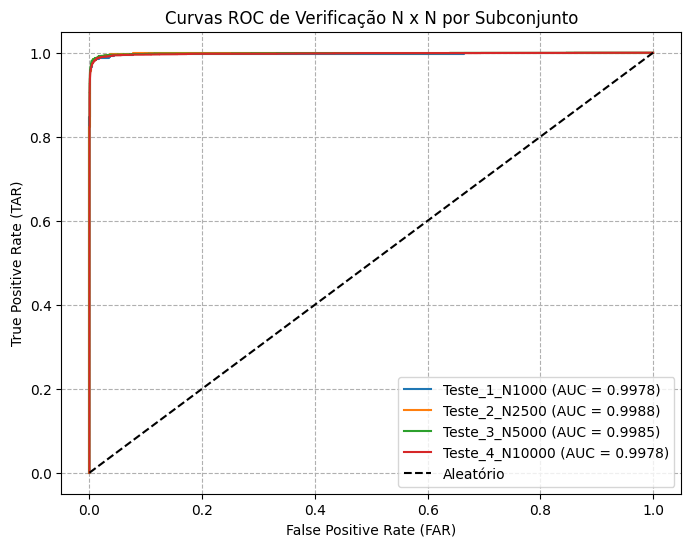

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# GRÁFICO 1: Curvas ROC
def plotar_curvas_roc(all_results):
    """
    Gera gráfico a partir dos resultados de avaliação N x N:
    1. Curvas ROC dos subsets.
    
    Args:
        all_results (dict): Dicionário contendo os resultados de todos os testes.
    """
    
    # 1. Preparação e Extração dos Dados
    test_names = []
    
    # Iterar sobre os resultados e extrair os dados
    for name, metrics in sorted(all_results.items()):
        # Ex: name = 'Teste_1_N1000' -> size = 1000
        size = int(name.split('N')[-1]) 
        test_names.append(f"N={size}")

    # -----------------------------------------------------------------
    # GRÁFICO: CURVAS ROC (Requer fpr e tpr salvos no JSON)
    # -----------------------------------------------------------------
    fig = plt.figure(figsize=(8, 6))
    
    # Assumindo que você ajustou o salvamento para incluir 'fpr' e 'tpr'
    has_roc_data = False
    for name, metrics in all_results.items():
        if 'fpr' in metrics and 'tpr' in metrics:
            has_roc_data = True
            
            # Converte lista salva no JSON de volta para np.array
            fpr = np.array(metrics['fpr']) 
            tpr = np.array(metrics['tpr'])
            roc_auc = metrics['ROC_AUC']
            
            plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})')
        
    if has_roc_data:
        plt.plot([0, 1], [0, 1], 'k--', label='Aleatório') 
        plt.xlabel('False Positive Rate (FAR)')
        plt.ylabel('True Positive Rate (TAR)')
        plt.title('Curvas ROC de Verificação N x N por Subconjunto')
        plt.legend(loc="lower right")
        plt.grid(linestyle='--')
        plt.show()

        return fig
    else:
        print("\n[AVISO] Dados de FPR/TPR não encontrados para plotar a Curva ROC. Pule esta etapa.")
        # Se não houver dados, retorne None
        plt.close(fig) # Fechar a figura vazia
        return None
   
# mostrar o gráfico
figura_roc = plotar_curvas_roc(resultados_salvos)
    

In [27]:
import matplotlib.pyplot as plt
import numpy as np

def plotar_precision_recall_f1_scores(all_results, threshold_type='F1'):
    """
    Gera gráfico de barras de Precision, Recall (TAR) e F1-score, 
    baseado no threshold ótimo de F1-score ou no threshold de EER.
    
    Args:
        all_results (dict): Dicionário contendo os resultados de todos os testes.
        threshold_type (str): 'F1' para métricas do F1-score ótimo (padrão) 
                              ou 'EER' para métricas do Threshold EER.
    """
    
    # 1. Configuração e Mapeamento de Chaves
    
    # Define as chaves de dicionário a serem usadas com base no threshold_type
    if threshold_type.upper() == 'EER':
        P_KEY = 'Precision_EER'
        R_KEY = 'Recall_EER'
        F1_KEY = 'F1-score_EER'
        title_suffix = 'no Threshold EER'
    elif threshold_type.upper() == 'F1':
        P_KEY = 'Precision'
        R_KEY = 'Recall'
        F1_KEY = 'F1-score'
        title_suffix = 'no Optimal Threshold (F1)'
    else:
        print("❌ Tipo de threshold inválido. Use 'F1' ou 'EER'.")
        return None
        
    # 2. Preparação e Extração dos Dados
    test_names = []
    precision_values = []
    recall_values = []
    f1_values = []
    
    # Classifica os resultados para garantir a ordem correta dos subconjuntos
    for name, metrics in sorted(all_results.items()):
        
        # Extrai o tamanho N para o rótulo (assumindo formato 'Teste_X_N[size]')
        try:
            size = int(name.split('N')[-1]) 
            test_names.append(f"N={size}")
        except:
            test_names.append(name) # Caso o formato não seja o esperado

        # Extração usando as chaves dinâmicas
        precision_values.append(metrics.get(P_KEY, 0))
        recall_values.append(metrics.get(R_KEY, 0)) 
        f1_values.append(metrics.get(F1_KEY, 0))
            
    # -----------------------------------------------------------------
    # 3. Geração do Gráfico de Barras
    # -----------------------------------------------------------------
    x = np.arange(len(test_names))
    width = 0.25
    
    fig, ax = plt.subplots(figsize=(10, 6))
    rects1 = ax.bar(x - width, precision_values, width, label='Precision')
    rects2 = ax.bar(x, recall_values, width, label='Recall (TAR)')
    rects3 = ax.bar(x + width, f1_values, width, label='F1-score')

    ax.set_ylabel('Score')
    ax.set_title(f'Métricas de Performance {title_suffix} por Subconjunto')
    ax.set_xticks(x)
    ax.set_xticklabels(test_names)
    ax.legend()
    ax.grid(axis='y', linestyle='--')
    plt.ylim(0, 1.05) # Ajusta o limite superior para melhor visualização
    
    # 4. Função Auxiliar para Rótulos (Valores acima das Barras)
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.4f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3), # 3 points offset
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=8)

    # Exibe os rótulos em todas as barras (como Precision e Recall são importantes)
    autolabel(rects1)
    autolabel(rects2)
    autolabel(rects3)

    plt.show()
    return fig

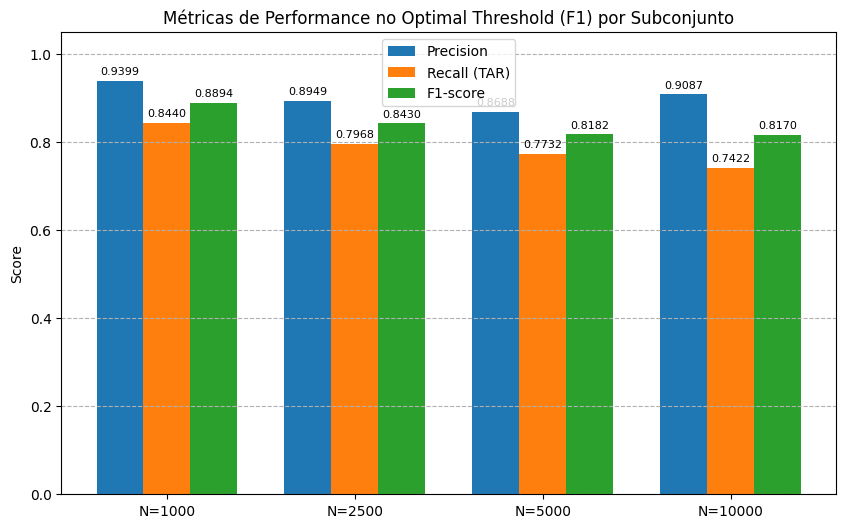

In [28]:
# 1. Plotar métricas baseadas no F1-score ótimo (default)
figura_f1_otimo = plotar_precision_recall_f1_scores(resultados_salvos, threshold_type='F1')

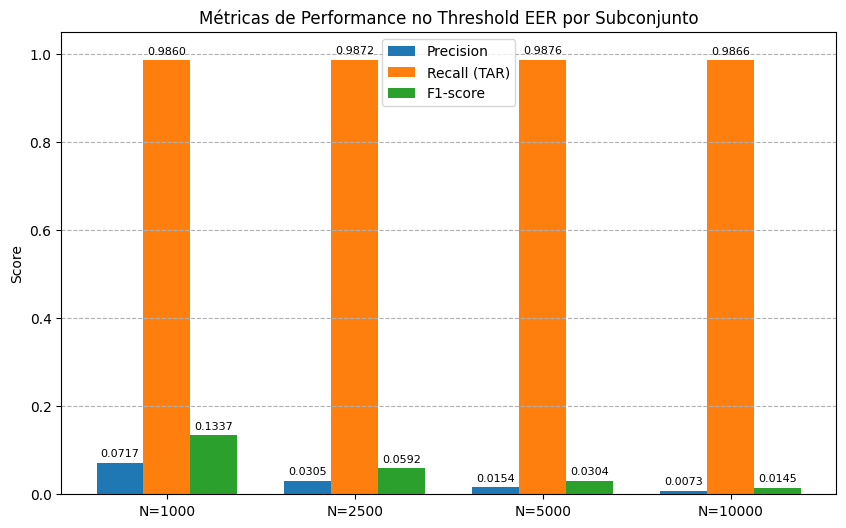

In [29]:
# 2. Plotar métricas baseadas no Threshold EER
figura_eer_otimo = plotar_precision_recall_f1_scores(resultados_salvos, threshold_type='EER')

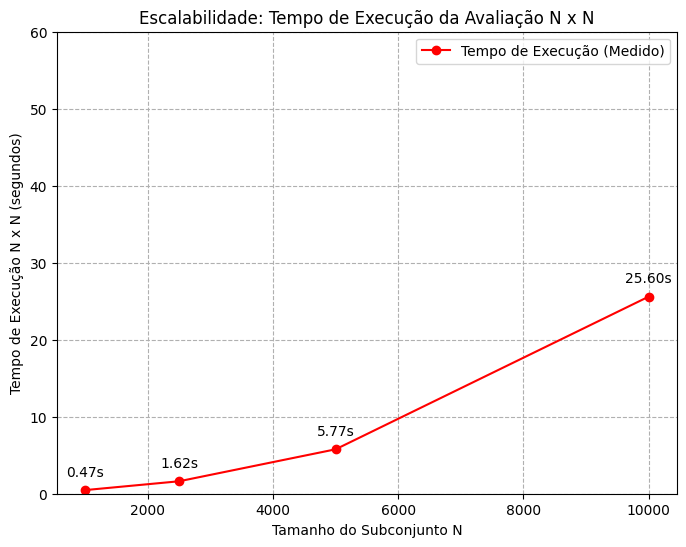

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# GRÁFICO 3: Tempo de avaliação de similaridade entre embeddings
def plotar_tempo_avaliacao(all_results):
    """
    Gera gráfico a partir dos resultados de avaliação N x N:
    1. Gráfico de linha do Tempo de Execução.
    
    Args:
        all_results (dict): Dicionário contendo os resultados de todos os testes.
    """
    
    # 1. Preparação e Extração dos Dados
    test_names = []
       
    # Dados para o Gráfico de Linha
    size_values = []
    time_values = []

    # Iterar sobre os resultados e extrair os dados
    for name, metrics in sorted(all_results.items()):
        # Ex: name = 'Teste_1_N1000' -> size = 1000
        size = int(name.split('N')[-1]) 
        test_names.append(f"N={size}")
        size_values.append(size)
        
        # Extração para o Gráfico de Linha
        time_values.append(metrics.get('Tempo_Execucao_s', 0))

    # -----------------------------------------------------------------
    # GRÁFICO: TEMPO DE EXECUÇÃO VS. TAMANHO DO SUBSET
    # -----------------------------------------------------------------
    fig = plt.figure(figsize=(8, 6))
    
    # Converte listas para arrays NumPy para plotagem
    size_values = np.array(size_values)
    time_values = np.array(time_values)
    
    # A avaliação N x N deve seguir aproximadamente uma função O(N^2)
    plt.plot(size_values, time_values, marker='o', linestyle='-', color='red', label='Tempo de Execução (Medido)')
    
    plt.xlabel('Tamanho do Subconjunto N')
    plt.ylabel('Tempo de Execução N x N (segundos)')
    plt.title('Escalabilidade: Tempo de Execução da Avaliação N x N')
    plt.legend()
    plt.grid(linestyle='--')
    plt.ylim(0, 60)
    
    # Adiciona rótulos de tempo nos pontos
    for i, txt in enumerate(time_values):
        plt.annotate(f'{txt:.2f}s', (size_values[i], time_values[i]), textcoords="offset points", xytext=(0,10), ha='center')

    return fig
    
    plt.show()

# mostrar gráfico
figura_tempo_avaliacao = plotar_tempo_avaliacao(resultados_salvos)

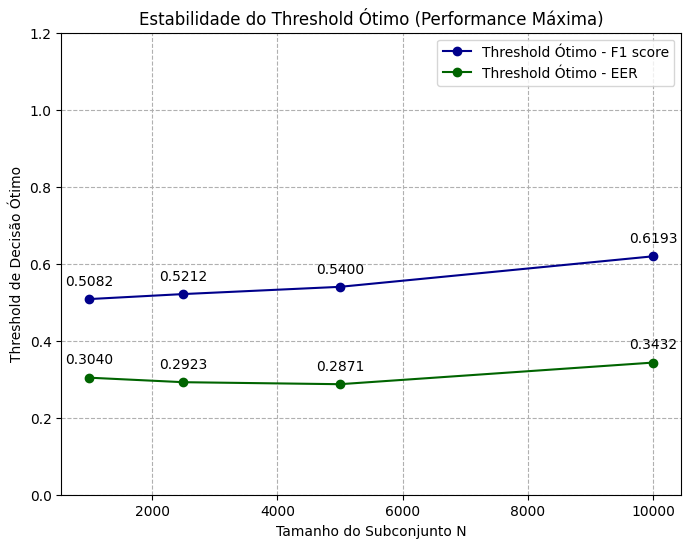

In [31]:
# GRÁFICO 4: THRESHOLD ÓTIMO VS. TAMANHO DO SUBSET
def plotar_threshold_otimo(all_results):
    
    threshold_values_f1 = []
    threshold_values_eer = []
    size_values = []
    
    # Extração de dados (mesmo loop de extração do Gráfico 3)
    for name, metrics in sorted(all_results.items()):
        size = int(name.split('N')[-1])
        size_values.append(size)
        threshold_values_f1.append(metrics.get('Optimal_Threshold', 0)) # baseado no F1 score
        threshold_values_eer.append(metrics.get('Threshold_EER', 0))

    size_values = np.array(size_values)
    threshold_values_f1 = np.array(threshold_values_f1)
    threshold_values_eer = np.array(threshold_values_eer)
    
    fig = plt.figure(figsize=(8, 6))
    
    plt.plot(size_values, threshold_values_f1, marker='o', linestyle='-', color='darkblue', label='Threshold Ótimo - F1 score')
    plt.plot(size_values, threshold_values_eer, marker='o', linestyle='-', color='darkgreen', label='Threshold Ótimo - EER')
    
    plt.xlabel('Tamanho do Subconjunto N')
    plt.ylabel('Threshold de Decisão Ótimo')
    plt.title('Estabilidade do Threshold Ótimo (Performance Máxima)')
    plt.ylim(0,1.2)
    
    # Adiciona rótulos de Threshold nos pontos
    for i, txt in enumerate(threshold_values_f1):
        plt.annotate(f'{txt:.4f}', (size_values[i], threshold_values_f1[i]), textcoords="offset points", xytext=(0,10), ha='center')

     # Adiciona rótulos de Threshold nos pontos
    for i, txt in enumerate(threshold_values_eer):
        plt.annotate(f'{txt:.4f}', (size_values[i], threshold_values_eer[i]), textcoords="offset points", xytext=(0,10), ha='center')

    plt.grid(linestyle='--')
    plt.legend()
    
    return fig
    
    plt.show()

# mostrar gráfico
figura_threshold_otimo = plotar_threshold_otimo(resultados_salvos)

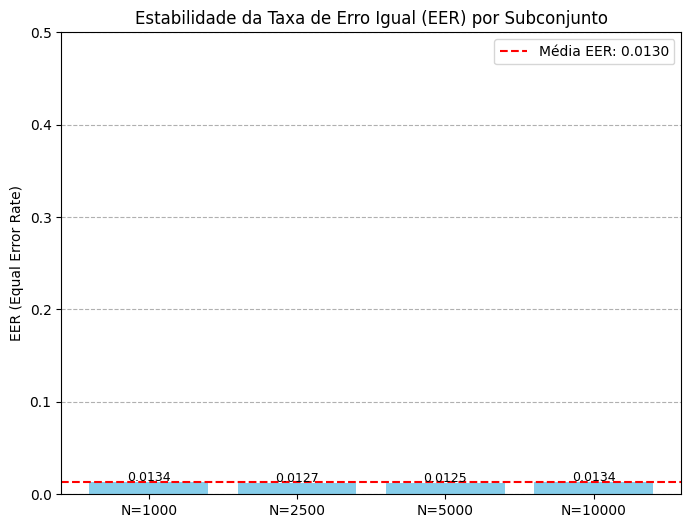

In [32]:
# GRÁFICO 5: EER POR SUBSET
def plotar_eer_barras(all_results):
    
    eer_values = []
    test_names = []
    
    for name, metrics in sorted(all_results.items()):
        size = int(name.split('N')[-1])
        test_names.append(f"N={size}")
        # Assumindo que 'EER' foi adicionado aos resultados
        eer_values.append(metrics.get('EER', 0.5)) 

    fig = plt.figure(figsize=(8, 6))
    x_pos = np.arange(len(test_names))
    
    plt.bar(x_pos, eer_values, color='skyblue')
    
    # Adicionar uma linha para a Média do EER (mantida)
    plt.axhline(np.mean(eer_values), color='red', linestyle='--', label=f'Média EER: {np.mean(eer_values):.4f}')
    
    plt.xticks(x_pos, test_names)
    plt.ylabel('EER (Equal Error Rate)')
    plt.title('Estabilidade da Taxa de Erro Igual (EER) por Subconjunto')
       
    # Adicionar os rótulos
    for i, v in enumerate(eer_values):
        # O valor é plotado ligeiramente acima da barra
        plt.text(i, v + 0.0005, f'{v:.4f}', ha='center', fontsize=9)
        
    # Ajuste do Limite do Eixo Y para evitar corte
    # Encontra o valor máximo do EER
    max_eer = np.max(eer_values)
    # Define o limite superior com uma margem de 10% acima do máximo
    # plt.ylim(0, max_eer * 1.10) # 1.10 = 10% de margem no topo. Ajuste esse valor se necessário.

    # ou define um limite superior
    plt.ylim(0, 0.5)

    plt.legend()
    plt.grid(axis='y', linestyle='--')

    return fig
    
    plt.show()

# mostrar gráfico
figura_eer_barras = plotar_eer_barras(resultados_salvos)

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

# GRÁFICO 6: MATRIZ DE CONFUSÃO 
def plotar_matrizes_confusao(all_results, threshold_type='F1'):
    """
    Gera e plota as Matrizes de Confusão, permitindo escolher o ponto de operação 
    (threshold) a ser plotado.

    Args:
        all_results (dict): Dicionário de resultados de um único fold (all_results), 
                            contendo 'Matriz_Confusao_EER' e 'Matriz_Confusao_F1'.
        threshold_type (str): 'EER' para plotar a CM no ponto de Equal Error Rate, 
                              'F1' para plotar a CM no ponto de F1-score máximo.
    """
    
    # 1. Configuração das Chaves e Cores
    if threshold_type.upper() == 'F1':
        cm_key = 'Matriz_Confusao_F1'
        thresh_key = 'Optimal_Threshold'
        metric_key = 'F1-score'
        cmap = 'Blues'
        title_prefix = 'Thresh F1'
    elif threshold_type.upper() == 'EER':
        cm_key = 'Matriz_Confusao_EER'
        thresh_key = 'Threshold_EER'
        metric_key = 'EER'
        cmap = 'Greens'
        title_prefix = 'Thresh EER'
    else:
        print("❌ Tipo de threshold inválido. Use 'EER' ou 'F1'.")
        return

    results_to_plot = {}

    # 2. Coleta e Formatação dos Dados
    for name, metrics in all_results.items():
        
        if cm_key in metrics:
            cm = metrics[cm_key]
            
            if isinstance(cm, np.ndarray) and cm.shape == (2, 2):
                
                # Obtendo métricas de contexto
                threshold_val = metrics.get(thresh_key, [0.5])
                if isinstance(threshold_val, list):
                    threshold_val = threshold_val[0]
                
                metric_val = metrics.get(metric_key, 0.5)
                if isinstance(metric_val, list):
                    metric_val = metric_val[0]

                # --- CÁLCULO DAS PORCENTAGENS (4 decimais) ---
                TN, FP, FN, TP = cm.ravel()
                
                sum_negativo = TN + FP
                sum_positivo = FN + TP
                
                # Evitar divisão por zero
                sum_negativo = sum_negativo if sum_negativo > 0 else 1 
                sum_positivo = sum_positivo if sum_positivo > 0 else 1
                
                # Porcentagens
                perc_TN = (TN / sum_negativo) * 100
                perc_FP = (FP / sum_negativo) * 100
                perc_FN = (FN / sum_positivo) * 100
                perc_TP = (TP / sum_positivo) * 100
                
                # Cria a matriz de anotação formatada
                labels = np.array([
                    [f'{TN}\n({perc_TN:.4f}%)', f'{FP}\n({perc_FP:.4f}%)'],
                    [f'{FN}\n({perc_FN:.4f}%)', f'{TP}\n({perc_TP:.4f}%)']
                ])
                
                results_to_plot[name] = {
                    'cm': cm,
                    'threshold': threshold_val,
                    'metric': metric_val,
                    'labels': labels
                }
            else:
                print(f"Aviso: Matriz de Confusão para {name} não está no formato 2x2 ou não é um array NumPy.")
        
    # 3. Plotagem
    if not results_to_plot:
        print(f"❌ Nenhuma Matriz de Confusão para '{cm_key}' encontrada no dicionário de resultados.")
        return

    num_plots = len(results_to_plot)
    num_cols = 2
    num_rows = math.ceil(num_plots / num_cols) 

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(7 * num_cols, 7 * num_rows))
    axes_flat = axes.flatten() 
        
    for i, (name, data) in enumerate(results_to_plot.items()):
        
        ax = axes_flat[i]
        cm = data['cm']
        threshold = data['threshold']
        metric_val = data['metric']
        
        # Tabela de Métricas Derivadas
        TN, FP, FN, TP = cm.ravel()
        
        # Cálculos de Taxas (para o título)
        sum_neg = TN + FP
        sum_pos = TP + FN
        FAR = FP / sum_neg if sum_neg > 0 else 0 
        TAR = TP / sum_pos if sum_pos > 0 else 0
        Precision = TP / (TP + FP) if (TP + FP) > 0 else 0
        
        # Montagem do Título
        if threshold_type.upper() == 'EER':
            title = (f"Subset {name} ({title_prefix}: {threshold:.4f})\n"
                     f"{metric_key}: {metric_val:.4f} | FAR: {FAR:.4f} | TAR: {TAR:.4f}")
        else: # F1
             title = (f"Subset {name} ({title_prefix}: {threshold:.4f})\n"
                     f"{metric_key}: {metric_val:.4f} | Precision: {Precision:.4f} | Recall/TAR: {TAR:.4f}")

        ax.set_title(title, fontsize=10)

        # Plotar Matriz 

        sns.heatmap(cm, annot=data['labels'], fmt='', cmap=cmap, cbar=False, 
                    xticklabels=['Rejeitado (0)', 'Aceito (1)'], 
                    yticklabels=['Negativo Real (0)', 'Positivo Real (1)'],
                    linewidths=.5, linecolor='gray', ax=ax)
        
        ax.set_ylabel('Rótulo Verdadeiro (Real Label)')
        ax.set_xlabel('Predição (Prediction)')

    # 4. Remover subplots vazios
    for i in range(num_plots, num_rows * num_cols):
        fig.delaxes(axes_flat[i])

    plt.tight_layout()

    return fig
    
    plt.show()

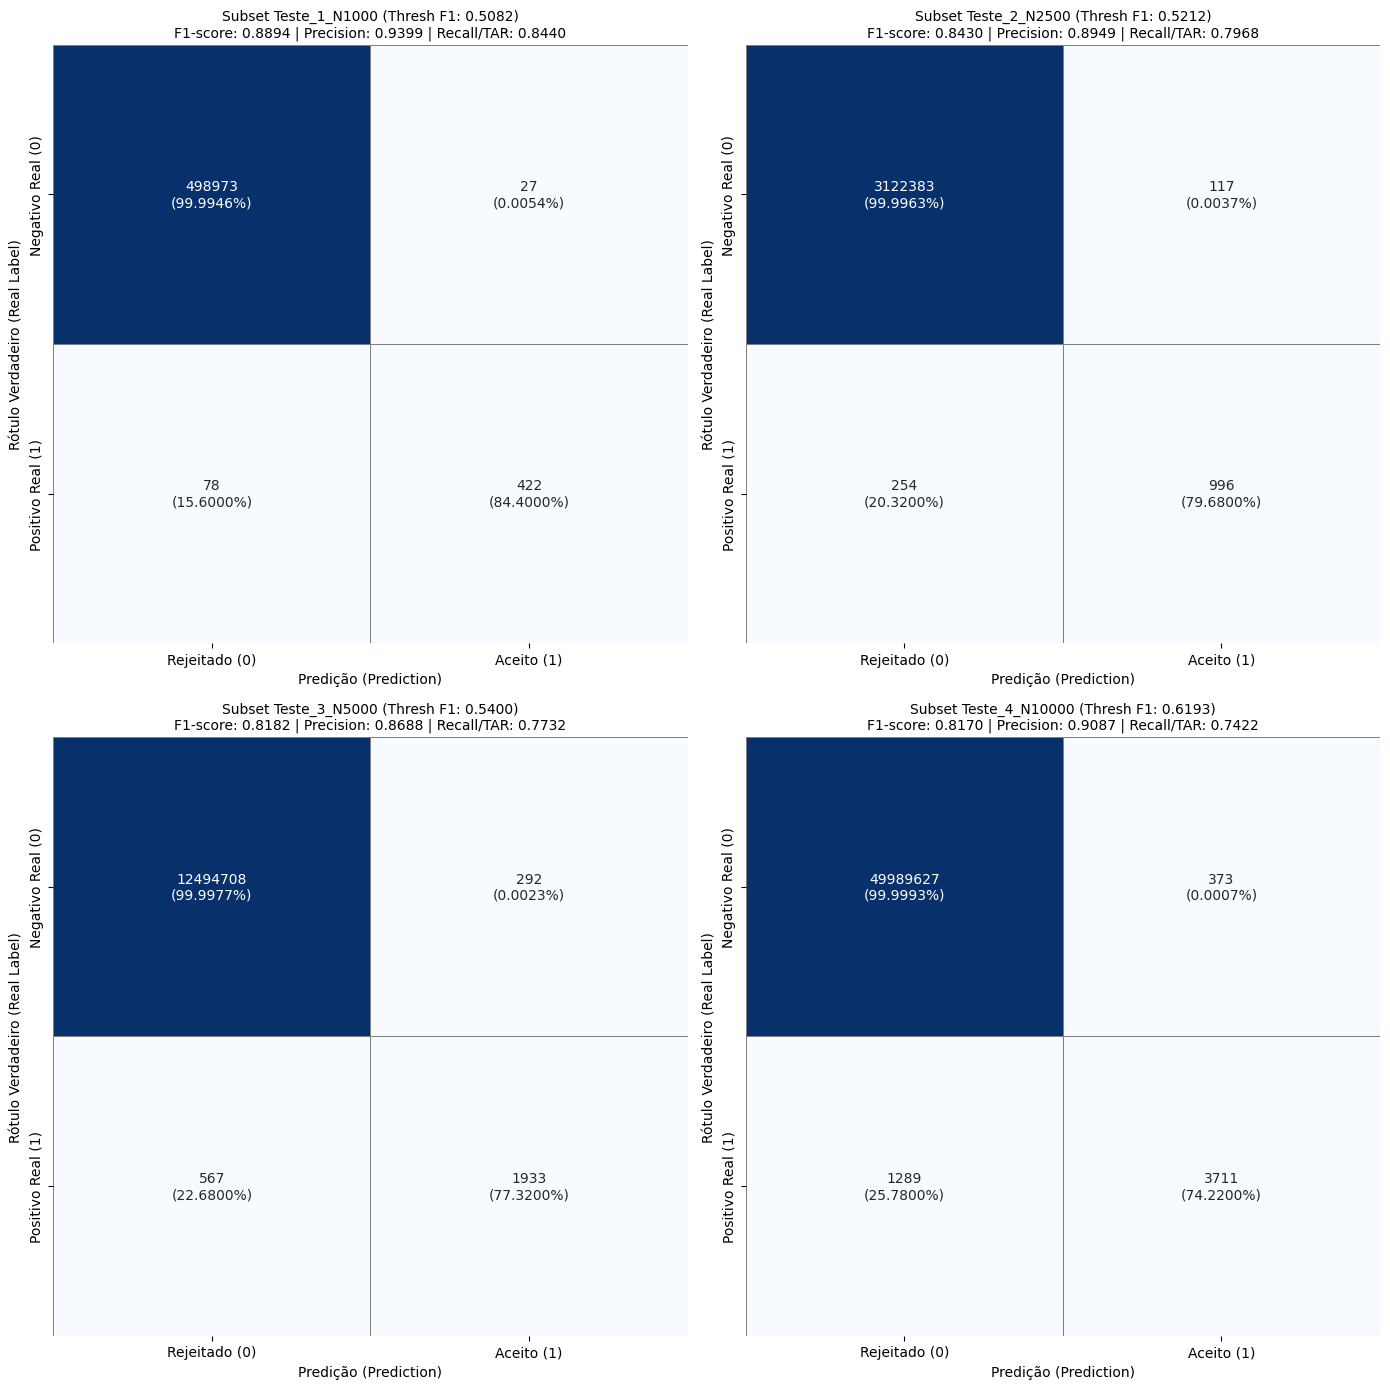

In [34]:
# 1. Linha Negativa (Impostores): Indica a capacidade do sistema de rejeitar impostores.
# 2. Linha Positiva (Genuínos): Indica a capacidade do sistema de aceitar genuínos.
    
figura_matriz_confusao_f1 = plotar_matrizes_confusao(all_results, threshold_type='F1')

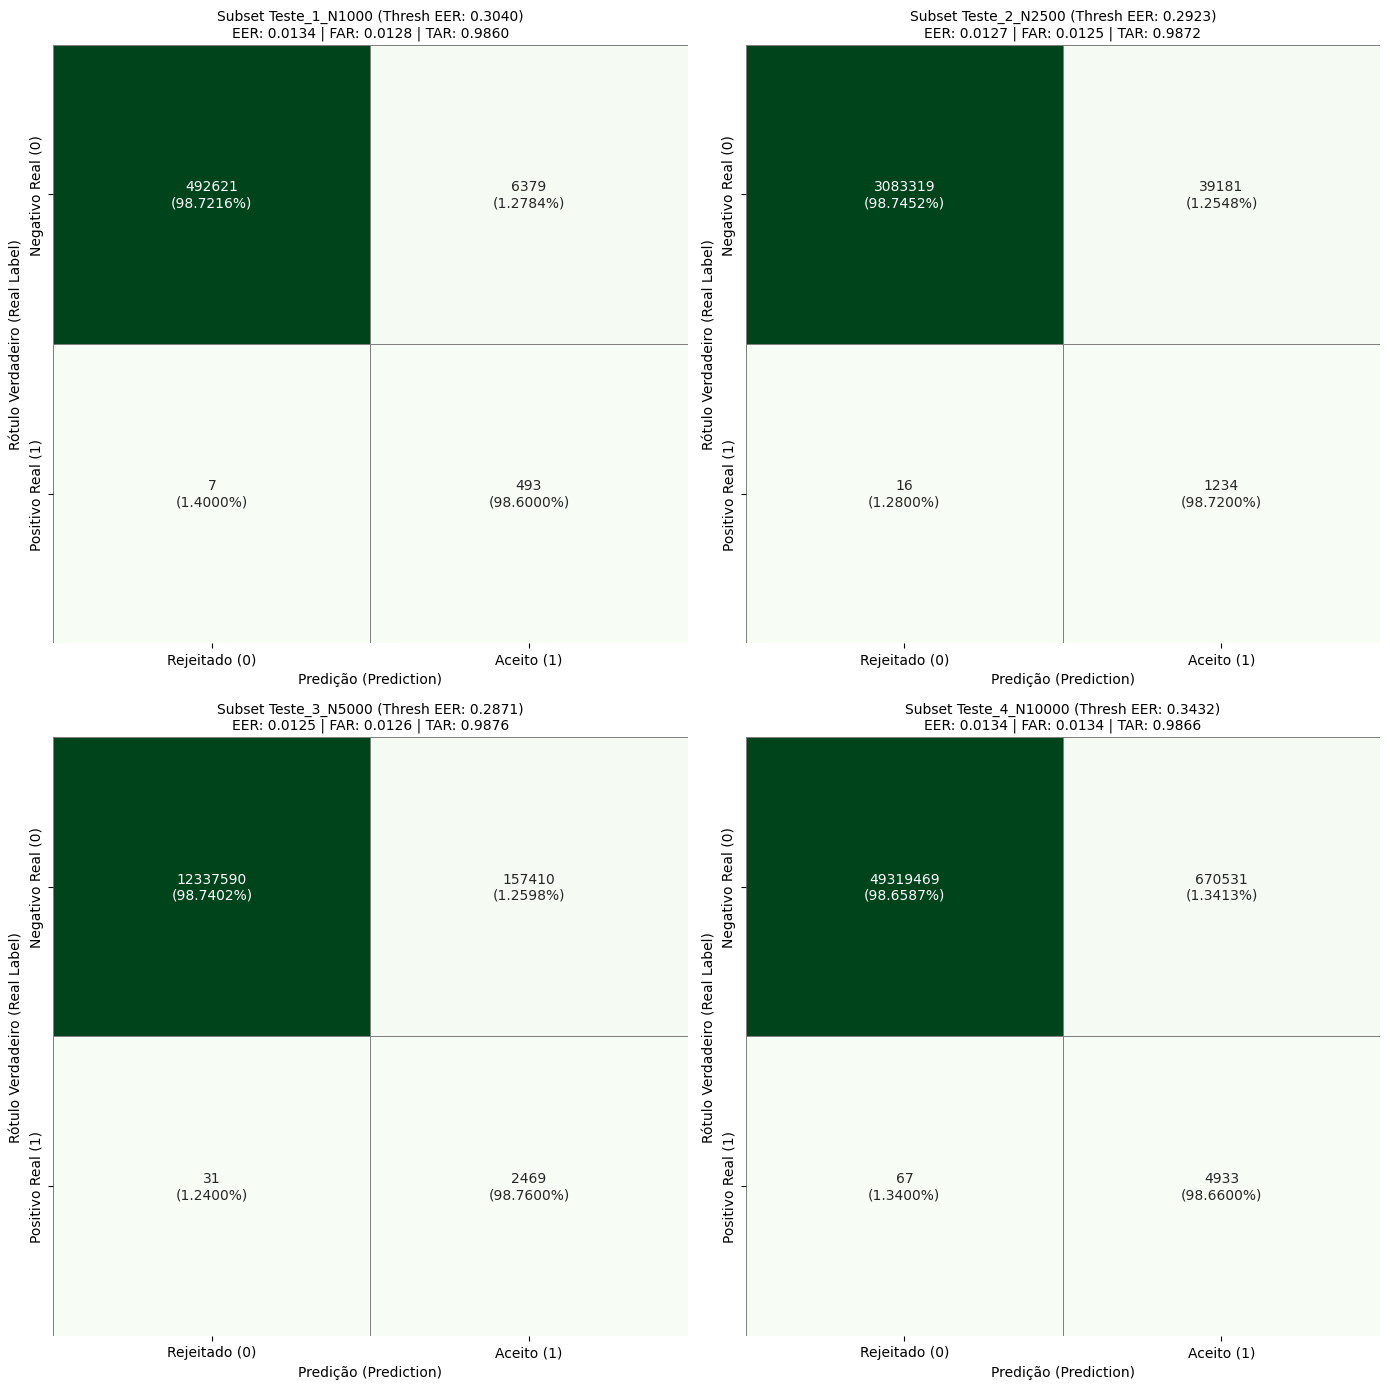

In [35]:
# 1. Linha Negativa (Impostores): Indica a capacidade do sistema de rejeitar impostores.
# 2. Linha Positiva (Genuínos): Indica a capacidade do sistema de aceitar genuínos.
    
figura_matriz_confusao_eer = plotar_matrizes_confusao(all_results, threshold_type='EER')

**Salvar figuras**

In [36]:
import matplotlib.pyplot as plt
import os

def salvar_figura(nome_arquivo, pasta_destino='figuras', fig=None, dpi=300, formato='jpg'):
    """
    Salva a figura atual do Matplotlib ou uma figura específica.

    Args:
        nome_arquivo (str): Nome do arquivo a ser salvo (sem extensão).
        pasta_destino (str): Nome da pasta onde a figura será salva.
                              Será criada se não existir. Default é 'figuras'.
        fig (matplotlib.figure.Figure, opcional): Objeto Figure a ser salvo. 
                                                  Se None, salva a figura atualmente ativa (plt.gcf()).
        dpi (int): Resolução da imagem em dots per inch. Default é 300.
        formato (str): Formato do arquivo (ex: 'png', 'pdf', 'svg', 'jpg'). Default é 'png'.
    """
    # 1. Obter a Figura
    # Se fig não for passado, usa a figura atual (plt.gcf() - Get Current Figure)
    if fig is None:
        fig = plt.gcf()

    # 2. Criar o caminho completo e a pasta de destino
    caminho_pasta = os.path.join(os.getcwd(), pasta_destino)
    
    # Garantir que a pasta exista
    if not os.path.exists(caminho_pasta):
        os.makedirs(caminho_pasta)
        print(f"-> Pasta criada: '{caminho_pasta}'")

    # 3. Definir o nome do arquivo com a extensão
    nome_completo = f"{nome_arquivo}.{formato}"
    caminho_completo = os.path.join(caminho_pasta, nome_completo)

    # 4. Salvar a figura
    try:
        fig.savefig(caminho_completo, dpi=dpi, format=formato, bbox_inches='tight')
        print(f"✅ Figura salva com sucesso em: {caminho_completo}")
    except Exception as e:
        print(f"❌ Erro ao salvar a figura: {e}")

In [37]:
figuras = [
    ('roc', figura_roc),
    ('f1-otimo', figura_f1_otimo),
    ('eer-otimo', figura_eer_otimo),
    ('tempo-avaliacao', figura_tempo_avaliacao),
    ('threshold-otimo', figura_threshold_otimo),
    ('eer-barras', figura_eer_barras),
    ('mc-f1', figura_matriz_confusao_f1),
    ('mc-eer', figura_matriz_confusao_eer),
]

for nome, fig in figuras:
    salvar_figura(
        nome_arquivo=f'{nome}-{model}',
        pasta_destino=PASTA_BASE,
        fig=fig,
        formato='jpg'
    )
    print(f"Figura '{nome}' salva com sucesso!")

✅ Figura salva com sucesso em: C:\Users\gralh\OneDrive\Desktop\NoLeak\Avaliacao-FFC-10k\roc-ArcFace.jpg
Figura 'roc' salva com sucesso!
✅ Figura salva com sucesso em: C:\Users\gralh\OneDrive\Desktop\NoLeak\Avaliacao-FFC-10k\f1-otimo-ArcFace.jpg
Figura 'f1-otimo' salva com sucesso!
✅ Figura salva com sucesso em: C:\Users\gralh\OneDrive\Desktop\NoLeak\Avaliacao-FFC-10k\eer-otimo-ArcFace.jpg
Figura 'eer-otimo' salva com sucesso!
✅ Figura salva com sucesso em: C:\Users\gralh\OneDrive\Desktop\NoLeak\Avaliacao-FFC-10k\tempo-avaliacao-ArcFace.jpg
Figura 'tempo-avaliacao' salva com sucesso!
✅ Figura salva com sucesso em: C:\Users\gralh\OneDrive\Desktop\NoLeak\Avaliacao-FFC-10k\threshold-otimo-ArcFace.jpg
Figura 'threshold-otimo' salva com sucesso!
✅ Figura salva com sucesso em: C:\Users\gralh\OneDrive\Desktop\NoLeak\Avaliacao-FFC-10k\eer-barras-ArcFace.jpg
Figura 'eer-barras' salva com sucesso!
✅ Figura salva com sucesso em: C:\Users\gralh\OneDrive\Desktop\NoLeak\Avaliacao-FFC-10k\mc-f1-ArcFac

In [38]:
"""salvar_figura(
    nome_arquivo='roc-DeepFace', 
    pasta_destino='Avaliacao-FFC-10k', 
    fig=figura_roc, 
    formato='jpg'
)

salvar_figura(
    nome_arquivo='f1-otimo-DeepFace', 
    pasta_destino='Avaliacao-FFC-10k', 
    fig=figura_f1_otimo, 
    formato='jpg'
)

salvar_figura(
    nome_arquivo='eer-otimo-DeepFace', 
    pasta_destino='Avaliacao-FFC-10k', 
    fig=figura_eer_otimo, 
    formato='jpg'
)

salvar_figura(
    nome_arquivo='tempo-avaliacao-DeepFace', 
    pasta_destino='Avaliacao-FFC-10k', 
    fig=figura_tempo_avaliacao, 
    formato='jpg'
)

salvar_figura(
    nome_arquivo='threshold-otimo-DeepFace', 
    pasta_destino='Avaliacao-FFC-10k', 
    fig=figura_threshold_otimo, 
    formato='jpg'
)

salvar_figura(
    nome_arquivo='eer-barras-DeepFace', 
    pasta_destino='Avaliacao-FFC-10k', 
    fig=figura_eer_barras, 
    formato='jpg'
)

salvar_figura(
    nome_arquivo='mc-f1-DeepFace', 
    pasta_destino='Avaliacao-FFC-10k', 
    fig=figura_matriz_confusao_f1, 
    formato='jpg'
)

salvar_figura(
    nome_arquivo='mc-eer-DeepFace', 
    pasta_destino='Avaliacao-FFC-10k', 
    fig=figura_matriz_confusao_eer, 
    formato='jpg'
)"""

"salvar_figura(\n    nome_arquivo='roc-DeepFace', \n    pasta_destino='Avaliacao-FFC-10k', \n    fig=figura_roc, \n    formato='jpg'\n)\n\nsalvar_figura(\n    nome_arquivo='f1-otimo-DeepFace', \n    pasta_destino='Avaliacao-FFC-10k', \n    fig=figura_f1_otimo, \n    formato='jpg'\n)\n\nsalvar_figura(\n    nome_arquivo='eer-otimo-DeepFace', \n    pasta_destino='Avaliacao-FFC-10k', \n    fig=figura_eer_otimo, \n    formato='jpg'\n)\n\nsalvar_figura(\n    nome_arquivo='tempo-avaliacao-DeepFace', \n    pasta_destino='Avaliacao-FFC-10k', \n    fig=figura_tempo_avaliacao, \n    formato='jpg'\n)\n\nsalvar_figura(\n    nome_arquivo='threshold-otimo-DeepFace', \n    pasta_destino='Avaliacao-FFC-10k', \n    fig=figura_threshold_otimo, \n    formato='jpg'\n)\n\nsalvar_figura(\n    nome_arquivo='eer-barras-DeepFace', \n    pasta_destino='Avaliacao-FFC-10k', \n    fig=figura_eer_barras, \n    formato='jpg'\n)\n\nsalvar_figura(\n    nome_arquivo='mc-f1-DeepFace', \n    pasta_destino='Avaliacao-FFC-1

In [39]:
import numpy as np
from sklearn.metrics.pairwise import euclidean_distances, cosine_similarity

def avaliar_top_k_manual_nos_subsets(all_embeddings_data, k_values=[1, 3, 5, 10], distance_metric='euclidean'):
    """
    Calcula a Taxa de Acerto Top-K (Identificação 1:N) para subsets, 
    LIDANDO MANUALMENTE com a não-unicidade dos rótulos e auto-comparação.

    Args:
        all_embeddings_data (dict): Dicionário onde a chave é o nome do subset 
                                    (ex: 'Teste_N1000') e o valor é uma tupla
                                    contendo: (embeddings_array, classes_array).
        k_values (list): Lista de valores de K a serem avaliados.
        distance_metric (str): Métrica de distância ('euclidean' ou 'cosine').
 
    Returns:
        dict: Dicionário aninhado com as taxas Top-K por subset.
    """
    top_k_results = {}
    
    for subset_name, data in all_embeddings_data.items():
        
        try:
            embeddings, classes = data
        except ValueError:
            continue
            
        num_samples = len(embeddings)
        
        if num_samples < 2:
            print(f"⚠️ Subset {subset_name} muito pequeno para Top-K (amostras < 2).")
            continue
        
        print(f"\n▶️ Processando Subset: {subset_name} (Amostras: {num_samples})")

        # 1. Calcular Matriz de Distâncias/Scores (Consulta vs. Base)
        if distance_metric == 'euclidean':
            distance_matrix = euclidean_distances(embeddings, embeddings)
            scores_matrix = -distance_matrix # Maior score = menor distância
            # Índice com menor distância (maior score) deve vir primeiro
            sort_indices = np.argsort(scores_matrix, axis=1)[:, ::-1] 
            
        elif distance_metric == 'cosine':
            scores_matrix = cosine_similarity(embeddings, embeddings)
            # Índice com maior similaridade deve vir primeiro
            sort_indices = np.argsort(scores_matrix, axis=1)[:, ::-1]
        else:
            raise ValueError("Métrica não suportada.")


        # 2. Avaliação Top-K Manual (para cada consulta i)
        
        subset_top_k = {f"Top{k}": 0 for k in k_values}
        num_correct = {k: 0 for k in k_values}
        
        for i in range(num_samples):
            
            query_class = classes[i]
            
            # Ranqueamento ordenado (índices da base ranqueados por score)
            ranked_indices = sort_indices[i]
            
            # --- Correção de Unicidade e Exclusão ---
            
            # 1. Encontra a posição da própria imagem (sempre a primeira se for distância=0)
            self_index_in_ranked = np.where(ranked_indices == i)[0]
            
            # 2. Exclui a própria imagem do ranqueamento (remove o primeiro ranqueamento)
            # Como a própria imagem tem a maior similaridade/menor distância, ela deve ser a primeira.
            # Se for uma das N imagens, o ranqueamento é feito contra N-1 imagens.
            ranked_indices_no_self = np.delete(ranked_indices, self_index_in_ranked[0])
            
            
            # 3. Ranqueamento Top-K (Apenas as K primeiras ranqueadas, após exclusão)
            # O máximo K necessário é o maior valor na lista k_values
            max_k = max(k_values)
            top_k_ranks = ranked_indices_no_self[:max_k]
            
            # Rótulos das imagens ranqueadas no Top K
            top_k_classes = classes[top_k_ranks]
            
            # 4. Verificação de Acerto
            # O acerto ocorre se a classe da consulta (query_class) estiver presente
            # em top_k_classes.
            
            is_correct_match = (top_k_classes == query_class)
            
            for k in k_values:
                # O acerto é True se a classe correta estiver em qualquer posição do ranqueamento Top K
                if np.any(is_correct_match[:k]):
                    num_correct[k] += 1
        
        # 5. Cálculo Final da Taxa de Acerto (Accuracy)
        for k in k_values:
            accuracy = num_correct[k] / num_samples
            subset_top_k[f"Top{k}"] = accuracy

        top_k_results[subset_name] = subset_top_k
        print(f"   Resultados Top-K Accuracy: {subset_top_k}")

    return top_k_results

In [40]:
classes = []
embeddings = []

# Iterar sobre cada imagem (chave) no dicionário
for path_image in face_embeddings_by_image:
    # Acessa o primeiro elemento [0], a chave ['label'], e a chave ['embedding']
    label = face_embeddings_by_image[path_image][0]['label']
    classes.append(label)
    img_embeddings = face_embeddings_by_image[path_image][0]['embedding']
    embeddings.append(img_embeddings)

classes = np.array(classes)
embeddings = np.array(embeddings)

print(f" Quantidade de classes: {len(classes)}")
print(f" Quantidade de embeddings: {len(embeddings)}")
print(f" Tamanho do vetor de embeddings: {len(embeddings[0])}")

 Quantidade de classes: 10000
 Quantidade de embeddings: 10000
 Tamanho do vetor de embeddings: 512


In [41]:
embeddings_N1000 = embeddings[0:1000]
classes_N1000 = classes[0:1000]

embeddings_N2500 = embeddings[0:2500]
classes_N2500 = classes[0:2500] 

embeddings_N5000 = embeddings[0:5000]
classes_N5000 = classes[0:5000] 

embeddings_N10000 = embeddings[0:10000]
classes_N10000 = classes[0:10000] 

all_embeddings_data = {
    'Teste_N1000': (embeddings_N1000, classes_N1000),
    'Teste_N2500': (embeddings_N2500, classes_N2500),
    'Teste_N5000': (embeddings_N5000, classes_N5000),
    'Teste_N10000': (embeddings_N10000, classes_N10000),
}

# 2. EXECUÇÃO DA AVALIAÇÃO
top_k_resultados = avaliar_top_k_manual_nos_subsets(
    all_embeddings_data=all_embeddings_data,
    k_values=[1, 3, 5, 10],
    distance_metric='cosine'
)


▶️ Processando Subset: Teste_N1000 (Amostras: 1000)
   Resultados Top-K Accuracy: {'Top1': 0.952, 'Top3': 0.972, 'Top5': 0.981, 'Top10': 0.987}

▶️ Processando Subset: Teste_N2500 (Amostras: 2500)
   Resultados Top-K Accuracy: {'Top1': 0.918, 'Top3': 0.956, 'Top5': 0.9676, 'Top10': 0.982}

▶️ Processando Subset: Teste_N5000 (Amostras: 5000)
   Resultados Top-K Accuracy: {'Top1': 0.8984, 'Top3': 0.9484, 'Top5': 0.9618, 'Top10': 0.9732}

▶️ Processando Subset: Teste_N10000 (Amostras: 10000)
   Resultados Top-K Accuracy: {'Top1': 0.9303, 'Top3': 0.9638, 'Top5': 0.9714, 'Top10': 0.98}


In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def visualizar_top_k_results(top_k_resultados, save_path=None, dpi=300):
    """
    Cria visualizações profissionais dos resultados Top-K Accuracy.
    
    Args:
        top_k_resultados (dict): Dicionário retornado pela função avaliar_top_k_manual_nos_subsets
        save_path (str): Caminho para salvar a figura (opcional)
        dpi (int): Resolução da imagem (padrão: 300 para qualidade publicação)
    """
    
    data_for_plot = []
    
    for subset_name, metrics in top_k_resultados.items():
        for top_k_name, accuracy in metrics.items():
            k_value = int(top_k_name.replace('Top', ''))
            data_for_plot.append({
                'Subset': subset_name.replace('Teste_', ''),
                'K': k_value,
                'Accuracy': accuracy * 100  # Converter para porcentagem
            })
    
    df = pd.DataFrame(data_for_plot)
    
    plt.rcParams['font.size'] = 10
    plt.rcParams['axes.labelsize'] = 11
    plt.rcParams['axes.titlesize'] = 12
    plt.rcParams['xtick.labelsize'] = 10
    plt.rcParams['ytick.labelsize'] = 10
    plt.rcParams['legend.fontsize'] = 9
    
    cores_personalizadas = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    palette = cores_personalizadas[:len(df['Subset'].unique())]
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    ax1 = axes[0]
    
    subsets = df['Subset'].unique()
    k_values = sorted(df['K'].unique())
    x = np.arange(len(k_values))
    width = 0.8 / len(subsets)
    
    for i, subset in enumerate(subsets):
        subset_data = df[df['Subset'] == subset].sort_values('K')
        offset = (i - len(subsets)/2 + 0.5) * width
        bars = ax1.bar(x + offset, subset_data['Accuracy'], width, 
                      label=subset, color=palette[i], edgecolor='black', linewidth=0.8)
        
        for bar in bars:
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}%', ha='center', va='bottom', fontsize=8)
    
    ax1.set_xlabel('Valor de K (Top-K)', fontweight='bold')
    ax1.set_ylabel('Taxa de Acerto (%)', fontweight='bold')
    ax1.set_title('Comparação Top-K Accuracy por Subset', fontweight='bold', pad=15)
    ax1.set_xticks(x)
    ax1.set_xticklabels([f'Top-{k}' for k in k_values])
    ax1.legend(title='Subset', loc='lower right', frameon=True)
    ax1.set_ylim(0, 105)
    ax1.grid(axis='y', alpha=0.3, linestyle='--')
    
    ax2 = axes[1]
    
    for i, subset in enumerate(subsets):
        subset_data = df[df['Subset'] == subset].sort_values('K')
        ax2.plot(subset_data['K'], subset_data['Accuracy'], 
                marker='o', linestyle='-', linewidth=2.5, markersize=10,
                color=palette[i], label=subset)
    
    ax2.set_xlabel('Valor de K (Top-K)', fontweight='bold')
    ax2.set_ylabel('Taxa de Acerto (%)', fontweight='bold')
    ax2.set_title('Evolução da Performance com Aumento de K', 
                  fontweight='bold', pad=15)
    ax2.legend(title='Subset', loc='lower right', frameon=True)
    ax2.set_ylim(0, 105)
    ax2.grid(True, alpha=0.3, linestyle='--')
    ax2.set_xticks(k_values)
    ax2.set_xticklabels([f'Top-{k}' for k in k_values])
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight', facecolor='white')
        print(f"Figura salva em: {save_path}")
    
    plt.show()
    
    print("\n" + "="*70)
    print("RESUMO ESTATÍSTICO - TOP-K ACCURACY")
    print("="*70)
    
    summary = df.groupby(['Subset', 'K'])['Accuracy'].mean().reset_index()
    pivot_table = summary.pivot(index='Subset', columns='K', values='Accuracy')
    
    print("\nTabela de Resultados (%):")
    print(pivot_table.to_string(float_format='%.2f'))
    
    print("\n" + "="*70)
    print("ANÁLISE DE MELHORIA")
    print("="*70)
    
    for subset in df['Subset'].unique():
        subset_data = df[df['Subset'] == subset].sort_values('K')
        top1 = subset_data[subset_data['K'] == 1]['Accuracy'].values[0]
        top10 = subset_data[subset_data['K'] == 10]['Accuracy'].values[0]
        improvement = top10 - top1
        
        print(f"\n{subset}:")
        print(f"  • Top-1:  {top1:.2f}%")
        print(f"  • Top-10: {top10:.2f}%")
        print(f"  • Ganho:  +{improvement:.2f}% (melhoria relativa: {(improvement/top1)*100:.1f}%)")

    
    

Figura salva em: top_k_accuracy_analysis.png


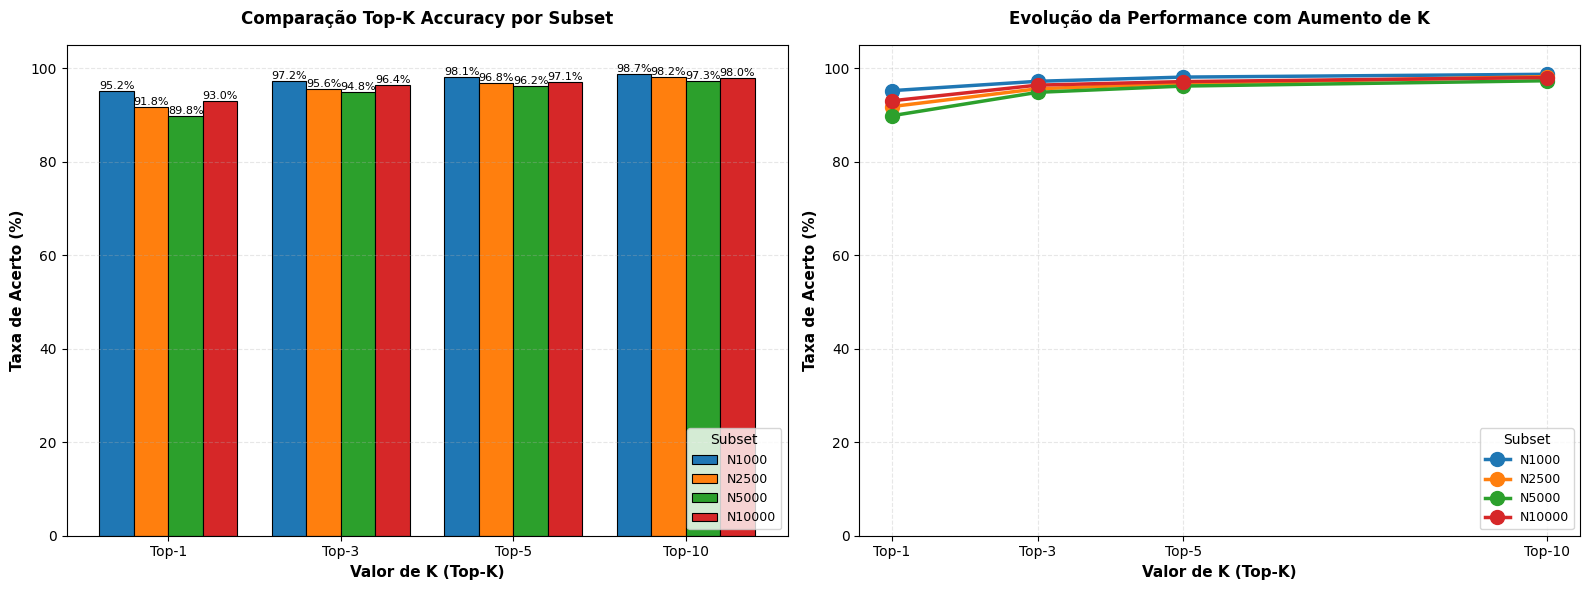


RESUMO ESTATÍSTICO - TOP-K ACCURACY

Tabela de Resultados (%):
K         1     3     5     10
Subset                        
N1000  95.20 97.20 98.10 98.70
N10000 93.03 96.38 97.14 98.00
N2500  91.80 95.60 96.76 98.20
N5000  89.84 94.84 96.18 97.32

ANÁLISE DE MELHORIA

N1000:
  • Top-1:  95.20%
  • Top-10: 98.70%
  • Ganho:  +3.50% (melhoria relativa: 3.7%)

N2500:
  • Top-1:  91.80%
  • Top-10: 98.20%
  • Ganho:  +6.40% (melhoria relativa: 7.0%)

N5000:
  • Top-1:  89.84%
  • Top-10: 97.32%
  • Ganho:  +7.48% (melhoria relativa: 8.3%)

N10000:
  • Top-1:  93.03%
  • Top-10: 98.00%
  • Ganho:  +4.97% (melhoria relativa: 5.3%)


In [43]:
visualizar_top_k_results(
        top_k_resultados,
        save_path='top_k_accuracy_analysis.png',  # ou None para não salvar
        dpi=300
    )

**### Parte 7 - Teste Estatístico ###**

**Executar a avaliação de embeddings multiplas vezes (folds)**

In [44]:
import random
import numpy as np
import os
import gc

def rodar_avaliacao_multipla_vezes(
    num_folds, 
    face_embeddings_by_image, 
    db_images_path_ord, 
    target_far, 
    target_tar,
    subsets_n=[1000, 2500, 5000], 
    sample_percentage=0.9, 
    use_gpu=True
):
    
    all_folds_results = {}

    print(f"Iniciando {num_folds} iterações (com amostragem aleatória) para análise estatística...")

    # --- 1. PRÉ-PROCESSAMENTO: IDENTIFICAR IDENTIDADES COM PARES ---
    identity_to_paths = {}
    for path in db_images_path:
        identity = os.path.basename(os.path.dirname(path))
        if identity not in identity_to_paths:
            identity_to_paths[identity] = []
        identity_to_paths[identity].append(path)
        
    pair_ready_identities = {
        identity: paths 
        for identity, paths in identity_to_paths.items() 
        if len(paths) >= 2
    }
    
    all_unique_identities = list(pair_ready_identities.keys())
    TOTAL_IDENTITIES_ELIGIBLE = len(all_unique_identities)
    
    if TOTAL_IDENTITIES_ELIGIBLE == 0:
        print("❌ Erro: Nenhuma identidade encontrada com 2 ou mais imagens.")
        return all_folds_results
        
    # N total estimado (para determinar o tamanho do último subset)
    n_total_estimate = sum(len(paths) for paths in pair_ready_identities.values())

    # --- 2. DEFINIÇÃO DAS CHAVES ESPERADAS NO FORMATO 'Teste_{i+1}_N{size}' ---
    
    # 2.1 Determina os tamanhos válidos (igual à função interna)
    valid_sizes = [s for s in subsets_n if s <= n_total_estimate]
    if n_total_estimate not in valid_sizes:
        valid_sizes.append(n_total_estimate)
    valid_sizes = sorted(list(set(valid_sizes)))

    # 2.2 Cria a lista de chaves esperadas com o prefixo 'Teste_i+1_Nsize'
    expected_subset_keys = []
    for i, size in enumerate(valid_sizes):
        expected_subset_keys.append(f'Teste_{i+1}_N{size}')
    
    print(f"Iniciando {num_folds} iterações (adaptado ao formato de chave: {expected_subset_keys})...")
    
    # --- 3. LOOP DE REPETIÇÃO COM AMOSTRAGEM ---
    
    for fold in range(num_folds):
        print(f"\n====================== INICIANDO FOLD {fold + 1}/{num_folds} ======================")
        
        # A) Amostragem Aleatória de Identidades Elegíveis
        num_to_sample = int(TOTAL_IDENTITIES_ELIGIBLE * sample_percentage)
        sampled_identities = random.sample(all_unique_identities, num_to_sample)
        
        # B) Reconstrução da Lista de Caminhos
        current_fold_paths = []
        for identity in sampled_identities:
            current_fold_paths.extend(pair_ready_identities[identity])
            
        random.shuffle(current_fold_paths)
        
        current_fold_results = {}
        
        try:
            print("  -> Chamando executar_avaliacao_nxn_dividida...")
            # C) Chama a sua função de avaliação
            current_fold_results = executar_avaliacao_nxn_dividida(
                face_embeddings_by_image, 
                current_fold_paths, 
                target_far, 
                target_tar, 
                subsets_n, 
                use_gpu
            )
        except Exception as e:
            print(f"\n🔴 ERRO FATAL AO EXECUTAR O FOLD {fold + 1}: {e}")
            import traceback
            traceback.print_exc()
            current_fold_results = {} # Garante que o dicionário seja esvaziado em caso de erro

        # D) Coleta os resultados usando as chaves padronizadas
        if current_fold_results:
            # print(f"  -> ✅ Coleta de resultados do fold {fold + 1} iniciada. Chaves retornadas: {current_fold_results.keys()}")
            
            for subset_key in current_fold_results.keys():
                
                                   
                if subset_key not in all_folds_results:
                    all_folds_results[subset_key] = {
                        'ROC_AUC': [], 
                        'Precision': [],  
                        'Recall': [],     
                        'F1-score': [], 
                        'fpr': [],  
                        'tpr': [],   
                        'EER': [],
                        'Threshold_EER': [],
                        'Tempo_Execucao_s': []
                    }
                
                results = current_fold_results[subset_key]
                
                # Garantir que o valor seja um float e não uma lista (se for uma lista de 1 elemento)
                # roc_auc_val = results['ROC_AUC']
                # if isinstance(roc_auc_val, list): roc_auc_val = roc_auc_val[0]

                roc_auc_val = results.get('ROC_AUC', [0])[0] if isinstance(results.get('ROC_AUC', 0), list) else results.get('ROC_AUC', 0)
                eer_val = results.get('EER', [0])[0] if isinstance(results.get('EER', 0), list) else results.get('EER', 0)

                all_folds_results[subset_key]['ROC_AUC'].append(roc_auc_val)
                all_folds_results[subset_key]['Precision'].append(results.get('Precision', 0))
                all_folds_results[subset_key]['Recall'].append(results.get('Recall', 0))
                all_folds_results[subset_key]['F1-score'].append(results['F1-score'])
                all_folds_results[subset_key]['fpr'].append(results.get('fpr', []))
                all_folds_results[subset_key]['tpr'].append(results.get('tpr', []))
                all_folds_results[subset_key]['EER'].append(eer_val)                                   
                all_folds_results[subset_key]['Threshold_EER'].append(results.get('Threshold_EER', 0)) 
                all_folds_results[subset_key]['Tempo_Execucao_s'].append(results['Tempo_Execucao_s'])

            print(f"  -> ✅ FOLD {fold + 1} CONCLUÍDO E COLETADO.")
        else:
            print(f"  -> 🔴 FOLD {fold + 1} IGNORADO: Função interna retornou resultados vazios.")

        # E) Limpeza de VRAM
        gc.collect()
        if use_gpu:
            try:
                 cp.cuda.runtime.free(0)
            except Exception:
                 pass 
            
    print("\n✅ Coleta de resultados concluída!")
    return all_folds_results

**Início da coleta de dados (execução dos folds)**

In [45]:
target_far = 0.01
target_tar = 0.99
num_folds = 5
subsets_n = [1000, 2000, 5000]
sample_percentage = 0.9

all_folds_results = rodar_avaliacao_multipla_vezes(
    num_folds, 
    face_embeddings_by_image, 
    db_images_path, 
    target_far, 
    target_tar, 
    subsets_n,
    sample_percentage,
    use_gpu=True
)


Iniciando 5 iterações (com amostragem aleatória) para análise estatística...
Iniciando 5 iterações (adaptado ao formato de chave: ['Teste_1_N1000', 'Teste_2_N2000', 'Teste_3_N5000', 'Teste_4_N10000'])...

====================== INICIANDO FOLD 1/5 ======================
  -> Chamando executar_avaliacao_nxn_dividida...

Matriz de Embeddings criada. Total N = 9000
  -> Movendo matriz de embeddings para a GPU (CuPy)...

--- INICIANDO TESTE 1: Primeiras 1000 imagens (N=1000) ---
  -> Calculando Matriz de Distância N x N na GPU ...
  -> Calculando Matriz de Similaridade (GPU, Chamada Única)...
  -> Optimal Threshold Encontrado: 0.6122
  -> ⏰ Tempo de Avaliação N x N: 0.25 segundos

--- INICIANDO TESTE 2: Primeiras 2000 imagens (N=2000) ---
  -> Calculando Matriz de Distância N x N na GPU ...
  -> Calculando Matriz de Similaridade (GPU, Chamada Única)...
  -> Optimal Threshold Encontrado: 0.6258
  -> ⏰ Tempo de Avaliação N x N: 0.97 segundos

--- INICIANDO TESTE 3: Primeiras 5000 imagens (N=5

**Teste estatístico**

In [46]:
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd # 🎯 Para Tukey HSD
import scikit_posthocs as sp # 🎯 Para Teste de Dunn, 
# Se você não tiver o scikit-posthocs, instale com: pip install scikit-posthocs

def analisar_diferencas_estatisticas_com_normalidade(all_folds_results, metric_name='ROC_AUC', alpha=0.05):
    """
    Realiza a análise estatística, incluindo testes de suposição e testes post-hoc 
    (Tukey HSD ou Dunn), dependendo da normalidade dos dados.
    """
    
    analysis_results = {}
    
    # 1. PREPARAÇÃO DOS DADOS E CRIAÇÃO DO DATAFRAME LONGO
    
    df_long = []
    subset_data = {}
    subset_labels = []
    data_is_normal = True 

    for key, metrics in all_folds_results.items():
        if metric_name in metrics:
            data = np.array(metrics[metric_name])
            
            if len(data) < 3:
                print(f"⚠️ Aviso: O Subset '{key}' tem menos de 3 amostras, pulando.")
                continue
                
            subset_data[key] = data
            subset_labels.append(key)
            
            # 🎯 CRIAÇÃO DO DATAFRAME LONGO para Post-hoc
            for value in data:
                df_long.append({
                    'Valor': value,
                    'Grupo': key # Usa o nome do subset como rótulo do grupo
                })

    df = pd.DataFrame(df_long)
    
    if len(subset_data) < 2:
        print(f"❌ Dados insuficientes para análise estatística na métrica: {metric_name}.")
        return None

    print(f"\n--- 📈 Análise Estatística para: {metric_name} ---")
    
    # 2. VERIFICAÇÃO DE NORMALIDADE (SHAPIRO-WILK)
    print("\n## 🔬 Teste de Normalidade (Shapiro-Wilk)")
    
    for label, data in subset_data.items():
        shapiro_w, p_value_shapiro = stats.shapiro(data)
        is_normal = p_value_shapiro >= alpha
        
        if not is_normal:
            data_is_normal = False
            
        print(f"[{label}] P-Value (Shapiro-Wilk): {p_value_shapiro:.4f}")
        print(f"    -> Conclusão: {'NORMAL (P >= 0.05)' if is_normal else 'NÃO-NORMAL (P < 0.05)'}")
        
        analysis_results[f'Shapiro_Wilk_{label}'] = {'P_Value': p_value_shapiro, 'Normal': is_normal}
        
    print("\n---")
    if data_is_normal:
        print("✅ Dados aptos para **ANOVA (Teste Paramétrico)**.")
    else:
        print("❌ Pelo menos um subset NÃO é normal. Recomendado **Kruskal-Wallis (Teste Não Paramétrico)**.")
        
    # 3. TESTE PRINCIPAL E POST-HOC
    
    data_for_test = [data for data in subset_data.values()]
    
    if data_is_normal:
        # A) ANOVA + Tukey HSD
        
        # Executa a ANOVA
        f_stat, p_value_anova = stats.f_oneway(*data_for_test)
        
        analysis_results['ANOVA'] = {
            'F_Statistic': f_stat,
            'P_Value': p_value_anova,
            'Significancia': "Diferença Estatisticamente Significativa" if p_value_anova < alpha else "Nenhuma Diferença Significativa Encontrada"
        }
        
        print("\n## 📊 Resultado da ANOVA")
        print(f"F-Statistic: {f_stat:.4f}")
        print(f"P-Value: {p_value_anova:.4e}")
        print(f"Resultado Final: {analysis_results['ANOVA']['Significancia']}")
        
        # 🎯 POST-HOC: Tukey HSD
        if p_value_anova < alpha:
            print("\n## 🧪 Teste Post-Hoc: Tukey HSD")
            # Usa o DataFrame longo para o Tukey HSD
            tukey = pairwise_tukeyhsd(endog=df['Valor'], groups=df['Grupo'], alpha=alpha)
            
            # Adiciona o resultado formatado (tabela) ao dicionário
            analysis_results['Tukey_HSD'] = tukey.summary().as_html()
            print(tukey) # Imprime a tabela de resultados no console
        
    else:
        # B) Kruskal-Wallis + Teste de Dunn
        
        # Executa o Kruskal-Wallis
        h_stat, p_value_kw = stats.kruskal(*data_for_test)

        analysis_results['Kruskal_Wallis'] = {
            'H_Statistic': h_stat,
            'P_Value': p_value_kw,
            'Significancia': "Diferença Estatisticamente Significativa" if p_value_kw < alpha else "Nenhuma Diferença Significativa Encontrada"
        }
        
        print("\n## 📊 Resultado do Kruskal-Wallis")
        print(f"H-Statistic: {h_stat:.4f}")
        print(f"P-Value: {p_value_kw:.4e}")
        print(f"Resultado Final: {analysis_results['Kruskal_Wallis']['Significancia']}")

        # 🎯 POST-HOC: Teste de Dunn
        if p_value_kw < alpha:
            print("\n## 🧪 Teste Post-Hoc: Teste de Dunn (Bonferroni)")
            # Usa o DataFrame longo para o Teste de Dunn
            dunn_resultado = sp.posthoc_dunn(df, val_col='Valor', group_col='Grupo', p_adjust='bonferroni')
            
            # Adiciona o resultado formatado (tabela) ao dicionário
            analysis_results['Teste_de_Dunn'] = dunn_resultado.to_html()
            print(dunn_resultado) # Imprime a matriz de p-valores no console

    return analysis_results

**Executar teste estatístico**

In [47]:
analysis_results = analisar_diferencas_estatisticas_com_normalidade(all_folds_results, metric_name='ROC_AUC', alpha=0.05)



--- 📈 Análise Estatística para: ROC_AUC ---

## 🔬 Teste de Normalidade (Shapiro-Wilk)
[Teste_1_N1000] P-Value (Shapiro-Wilk): 0.0011
    -> Conclusão: NÃO-NORMAL (P < 0.05)
[Teste_2_N2000] P-Value (Shapiro-Wilk): 0.9303
    -> Conclusão: NORMAL (P >= 0.05)
[Teste_3_N5000] P-Value (Shapiro-Wilk): 0.4882
    -> Conclusão: NORMAL (P >= 0.05)
[Teste_4_N9000] P-Value (Shapiro-Wilk): 0.8304
    -> Conclusão: NORMAL (P >= 0.05)

---
❌ Pelo menos um subset NÃO é normal. Recomendado **Kruskal-Wallis (Teste Não Paramétrico)**.

## 📊 Resultado do Kruskal-Wallis
H-Statistic: 3.7314
P-Value: 2.9196e-01
Resultado Final: Nenhuma Diferença Significativa Encontrada


**Visualizar os resultados do teste estatístico**

In [48]:
import numpy as np
import matplotlib.pyplot as plt

def calcular_roc_media(all_tprs, all_fprs):
    """
    Calcula a Curva ROC Média (Mean ROC Curve) a partir de múltiplos folds.
    """
    mean_fpr = np.linspace(0, 1, 100)
    tprs = []

    for fpr, tpr in zip(all_fprs, all_tprs):
        tprs.append(np.interp(mean_fpr, fpr, tpr))
        
    mean_tpr = np.mean(tprs, axis=0)
    std_tpr = np.std(tprs, axis=0)

    mean_tpr[0] = 0.0
    mean_tpr[-1] = 1.0

    return mean_fpr, mean_tpr, std_tpr

In [49]:
# %matplotlib inline

def plotar_analise_agregada(all_folds_results):
    """
    Gera gráficos agregados (média e desvio-padrão) a partir de all_folds_results
    (resultados de múltiplos folds).
    """
    
    # 1. Agregação e Extração dos Dados
    aggregated_metrics = {}
    
    # Dados para o Gráfico de Barras e Linha
    subset_names = []
    subset_sizes = []
    
    # Itera sobre cada subset (ex: 'Teste_1_N1000')
    for name, fold_data in all_folds_results.items():
        
        # Extrai o tamanho N para o gráfico de linha
        size = int(name.split('N')[-1])
        subset_sizes.append(size)
        subset_names.append(f"N={size}")

        # Dicionário para armazenar a média de todas as métricas para este subset
        aggregated_metrics[name] = {}
        
        # Agregação Simples (Média e Desvio-Padrão)
        for metric_name, values in fold_data.items():
            if metric_name in ['fpr', 'tpr', 'scores_array', 'y_true_array']:
                continue
            
            # Verifica se o array de valores é válido para cálculo
            if len(values) == 0:
                # Se não houver dados (por exemplo, EER ficou vazio), use 0 como padrão
                mean_val = 0.0
                std_val = 0.0
            else:
                values_array = np.array(values)
                mean_val = np.mean(values_array)
                std_val = np.std(values_array)
        
            # Armazena a Média e o Desvio-Padrão (Isso deve gerar 'Mean_EER')         
            aggregated_metrics[name][f'Mean_{metric_name}'] = np.mean(values_array)
            aggregated_metrics[name][f'Std_{metric_name}'] = np.std(values_array)
            
        # Agregação Especial para ROC (fpr e tpr)
        if 'fpr' in fold_data and 'tpr' in fold_data and fold_data['fpr'] and fold_data['tpr']:

            # Garanta que os FPRs e TPRs sejam arrays numpy antes de passar para a função
            all_fprs = [np.array(f) for f in fold_data['fpr'] if f]
            all_tprs = [np.array(t) for t in fold_data['tpr'] if t]

            # Se houver dados válidos para a média
            if all_fprs:
                mean_fpr, mean_tpr, std_tpr = calcular_roc_media(all_tprs, all_fprs)
                aggregated_metrics[name]['Mean_FPR'] = mean_fpr
                aggregated_metrics[name]['Mean_TPR'] = mean_tpr
                aggregated_metrics[name]['Std_TPR'] = std_tpr

    # -----------------------------------------------------------------
    # GRÁFICO 1: CURVAS ROC MÉDIAS
    # -----------------------------------------------------------------
    fig1 = plt.figure(figsize=(10, 7))
    has_roc_data = False
    
    # Plota a Curva ROC Média para cada subset
    for name, metrics in aggregated_metrics.items():
        if 'Mean_FPR' in metrics:
            has_roc_data = True
            
            mean_fpr = metrics['Mean_FPR']
            mean_tpr = metrics['Mean_TPR']
            std_tpr = metrics['Std_TPR']
            mean_auc = metrics['Mean_ROC_AUC']
            
            # Linha Média
            plt.plot(mean_fpr, mean_tpr, label=f'{name} (Média AUC = {mean_auc:.4f})', lw=2)
            
            # Área de Desvio-Padrão (Error Band)
            tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
            tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
            plt.fill_between(mean_fpr, tprs_lower, tprs_upper, color='grey', alpha=.2,
                             label=f'+/- 1 Std Dev ({name.split("_")[-1]})')

            # ADICIONAR O PONTO DE THRESHOLD ÓTIMO (EER)
        
            # Escolhemos o Threshold EER Médio como o ponto de operação para este exemplo
            # Você pode trocar por 'Mean_Optimal_Threshold' se preferir o ponto de F1 máximo
            threshold_to_find = metrics.get('Mean_Threshold_EER', None) 
            
            if threshold_to_find is not None:
                
                # Encontra o índice na Curva ROC Média que corresponde ao Threshold
                # Nota: O array 'thresholds' não está diretamente disponível aqui,
                # mas podemos encontrar o FPR e TPR que correspondem ao valor do EER médio.
                
                # A forma mais simples (e correta, dada a estrutura) é usar o ponto de EER
                # que já foi encontrado na agregação.
                
                # O ponto EER é FAR = EER e TAR = 1 - EER (se FAR e FRR forem exatamente iguais)
                
                # 1. Encontra o índice onde Mean_FPR é mais próximo do Mean_EER
                mean_eer_val = metrics.get('Mean_EER', 0.5)
                
                # 2. Encontra o ponto na curva ROC média que tem o menor erro em relação ao EER
                # Índice onde a diferença absoluta entre FAR e FRR é mínima.
                frr_mean = 1 - mean_tpr
                eer_index_mean = np.argmin(np.abs(frr_mean - mean_fpr))
                
                # Coordenadas do ponto EER na Curva Média
                eer_fpr = mean_fpr[eer_index_mean]
                eer_tpr = mean_tpr[eer_index_mean]
                
                # 3. Plota o marcador no ponto EER
                plt.plot(eer_fpr, eer_tpr, 
                         marker='*', markersize=12, 
                         color='black', markeredgecolor='white', 
                         label=f'Ponto EER Médio ({name})', zorder=10) # zorder garante que o ponto esteja no topo

    
    if has_roc_data:
        plt.plot([0, 1], [0, 1], 'k--', label='Aleatório')
        plt.xlabel('False Positive Rate (FAR)')
        plt.ylabel('True Positive Rate (TAR)')
        plt.title('Curvas ROC Médias com Desvio-Padrão (Cross-Fold)')
        plt.legend(loc="lower right")
        plt.grid(linestyle='--')
        plt.show()

    # -----------------------------------------------------------------
    # GRÁFICO 2: MÉTRICAS (F1-score e EER)
    # -----------------------------------------------------------------
    
    # Extração dos valores médios e desvios para o gráfico de barras/linha
    mean_f1 = [m['Mean_F1-score'] for m in aggregated_metrics.values()]
    std_f1 = [m['Std_F1-score'] for m in aggregated_metrics.values()]
    
    mean_eer = [m['Mean_EER'] for m in aggregated_metrics.values()]
    std_eer = [m['Std_EER'] for m in aggregated_metrics.values()]
    
    # Gráfico de Barras para F1-Score
    x_f1 = np.arange(len(subset_names))
    fig2, ax = plt.subplots(figsize=(10, 6))
    
    # Barras para a Média do F1-score
    rects1 = ax.bar(x_f1, mean_f1, 0.4, label='Média F1-score', color='skyblue', yerr=std_f1, capsize=5)

    ax.set_ylabel('Média F1-score')
    ax.set_title('Média do F1-score com Desvio-Padrão (por Subconjunto)')
    ax.set_xticks(x_f1)
    ax.set_xticklabels(subset_names)
    
    # Adicionar os valores médios nas barras
    for rect in rects1:
        height = rect.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)
    
    ax.grid(axis='y', linestyle='--')
    plt.show()

    # -----------------------------------------------------------------
    # GRÁFICO 3: EER VS. TAMANHO DO SUBSET
    # -----------------------------------------------------------------
    
    fig3 = plt.figure(figsize=(10, 7))
    
    # Gráfico de Linha do EER Médio
    plt.errorbar(subset_sizes, mean_eer, yerr=std_eer, fmt='-o', capsize=5, color='darkred', label='Média EER (+/- Std Dev)')
    
    plt.xlabel('Tamanho do Subconjunto N')
    plt.ylabel('Média EER (Equal Error Rate)')
    plt.title('Estabilidade da Média EER (Cross-Fold)')
    plt.legend()
    plt.grid(linestyle='--')
    
    # Adiciona rótulos de EER Médio nos pontos
    for i, txt in enumerate(mean_eer):
        plt.annotate(f'{txt:.4f}', (subset_sizes[i], mean_eer[i]), textcoords="offset points", xytext=(0,10), ha='center')

    plt.show()

    # -----------------------------------------------------------------
    # GRÁFICO 4: MÉDIA DE PRECISION, RECALL E F1-SCORE (CROSS-FOLD)
    # -----------------------------------------------------------------
    
    # 1. Preparação dos dados
    subset_names = [name.split('N')[-1] for name in aggregated_metrics.keys()]
    
    # Extração dos valores médios
    mean_precision = [m.get('Mean_Precision', 0.0) for m in aggregated_metrics.values()]
    std_precision = [m.get('Std_Precision', 0.0) for m in aggregated_metrics.values()]
    
    mean_recall = [m.get('Mean_Recall', 0.0) for m in aggregated_metrics.values()]
    std_recall = [m.get('Std_Recall', 0.0) for m in aggregated_metrics.values()]
    
    mean_f1 = [m.get('Mean_F1-score', 0.0) for m in aggregated_metrics.values()]
    std_f1 = [m.get('Std_F1-score', 0.0) for m in aggregated_metrics.values()]
    
    
    # 2. Configuração do Gráfico de Barras Agrupadas
    x = np.arange(len(subset_names))  # Posições dos subconjuntos (grupos)
    width = 0.25  # Largura de cada barra
    
    fig4, ax = plt.subplots(figsize=(10, 6))
    
    # Barras de Precision (Primeiro grupo)
    rects1 = ax.bar(x - width, mean_precision, width, 
                    label='Precision Média', color='skyblue', 
                    yerr=std_precision, capsize=5)
    
    # Barras de Recall (Segundo grupo - no centro)
    rects2 = ax.bar(x, mean_recall, width, 
                    label='Recall Média', color='lightcoral', 
                    yerr=std_recall, capsize=5)
    
    # Barras de F1-score (Terceiro grupo)
    rects3 = ax.bar(x + width, mean_f1, width, 
                    label='F1-score Média', color='mediumseagreen', 
                    yerr=std_f1, capsize=5)
    
    
    # 3. Formatação e Rótulos
    ax.set_ylabel('Média da Métrica')
    ax.set_xlabel('Tamanho do Subconjunto N')
    ax.set_title('Estabilidade das Métricas de Classificação (Precision, Recall, F1) por Subconjunto')
    ax.set_xticks(x)
    ax.set_xticklabels([f"N={n}" for n in subset_names])
    ax.legend()
    ax.set_ylim(bottom=0.5, top=1.05) # Ajustar o limite inferior para focar na performance
    
    
    # Função auxiliar para adicionar os valores numéricos nas barras
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()

            vertical_offset = 20
            
            ax.annotate(f'{height:.3f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, vertical_offset),  # points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=8)
    
    autolabel(rects1)
    autolabel(rects2)
    autolabel(rects3)
    
    fig4.tight_layout()
    plt.grid(axis='y', linestyle='--')
    plt.show()

    return fig1, fig2, fig3, fig4

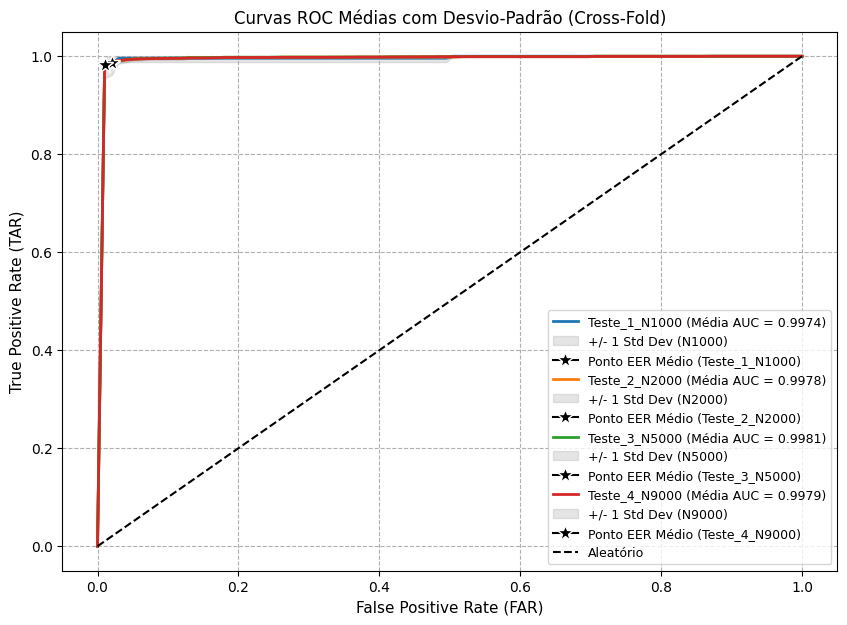

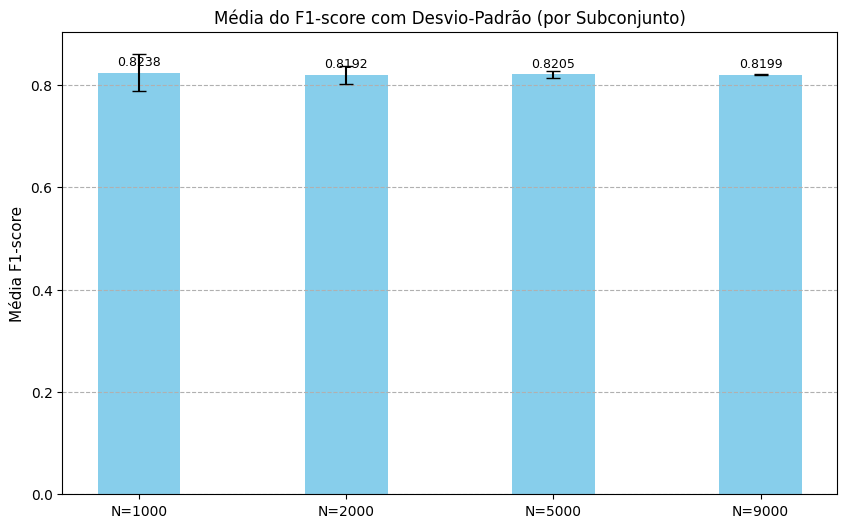

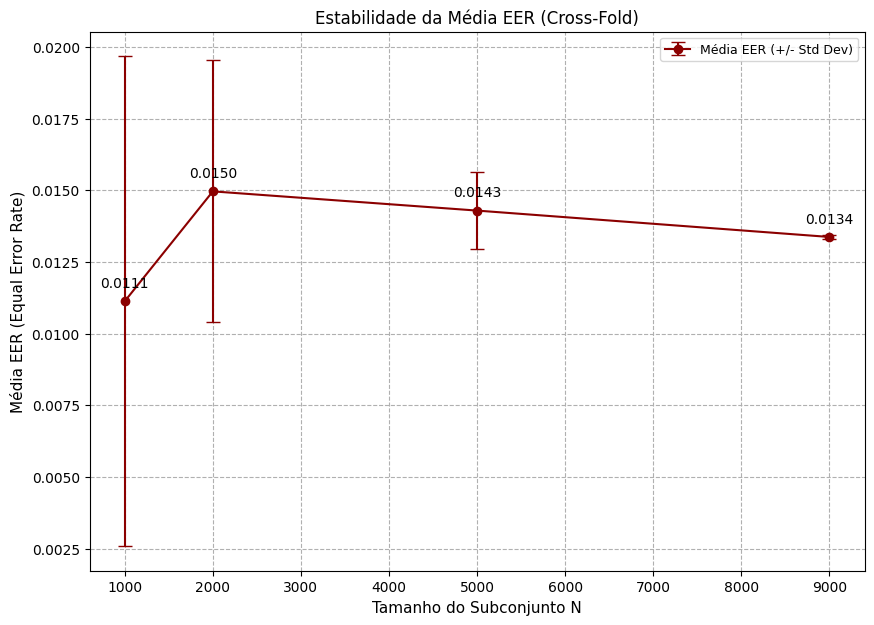

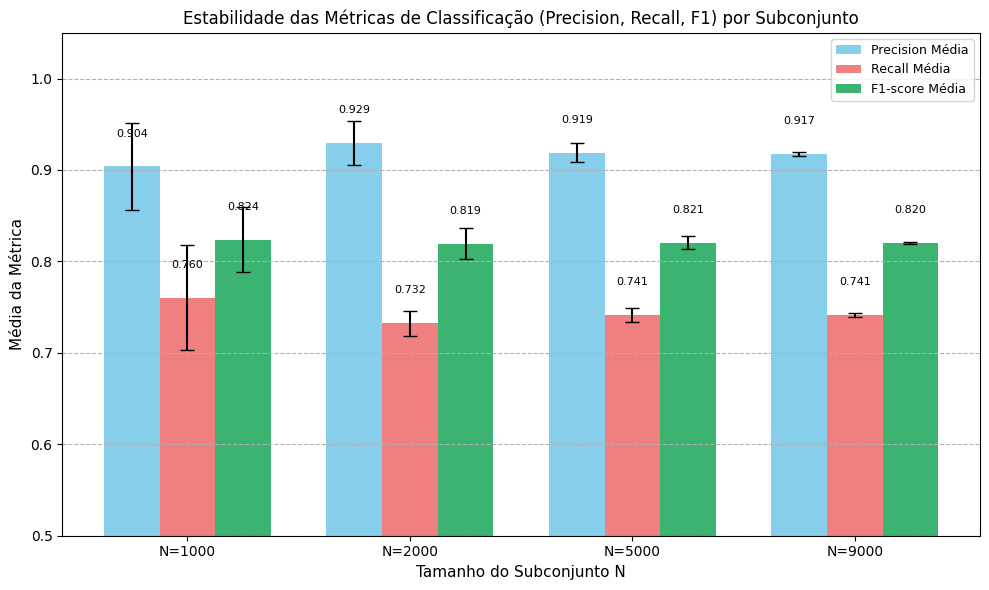

In [50]:
estatistica_roc, estatistica_f1, estatistica_eer, estatistica_precision_recall_f1 = plotar_analise_agregada(all_folds_results)

**Salvar figuras do teste estatístico**

In [51]:
estatisticas = [
    ('estatistica-media-roc', estatistica_roc),
    ('estatistica-media-f1', estatistica_f1),
    ('estatistica-media-eer', estatistica_eer),
    ('estatistica-media-precision-recall-f1', estatistica_precision_recall_f1),
]

for nome, fig in estatisticas:
    salvar_figura(
        nome_arquivo=f'{nome}-{model}',
        pasta_destino=PASTA_BASE,
        fig=fig,
        formato='jpg'
    )
    print(f"Estatística '{nome}' salva com sucesso!")

✅ Figura salva com sucesso em: C:\Users\gralh\OneDrive\Desktop\NoLeak\Avaliacao-FFC-10k\estatistica-media-roc-ArcFace.jpg
Estatística 'estatistica-media-roc' salva com sucesso!
✅ Figura salva com sucesso em: C:\Users\gralh\OneDrive\Desktop\NoLeak\Avaliacao-FFC-10k\estatistica-media-f1-ArcFace.jpg
Estatística 'estatistica-media-f1' salva com sucesso!
✅ Figura salva com sucesso em: C:\Users\gralh\OneDrive\Desktop\NoLeak\Avaliacao-FFC-10k\estatistica-media-eer-ArcFace.jpg
Estatística 'estatistica-media-eer' salva com sucesso!
✅ Figura salva com sucesso em: C:\Users\gralh\OneDrive\Desktop\NoLeak\Avaliacao-FFC-10k\estatistica-media-precision-recall-f1-ArcFace.jpg
Estatística 'estatistica-media-precision-recall-f1' salva com sucesso!


In [ ]:
"""salvar_figura(
    nome_arquivo='estatistica-media-roc-DeepFace', 
    pasta_destino='Avaliacao-FFC-10k', 
    fig=estatistica_roc, 
    formato='jpg'
)

salvar_figura(
    nome_arquivo='estatistica-media-f1-DeepFace', 
    pasta_destino='Avaliacao-FFC-10k', 
    fig=estatistica_f1, 
    formato='jpg'
)

salvar_figura(
    nome_arquivo='estatistica-media-eer-DeepFace', 
    pasta_destino='Avaliacao-FFC-10k', 
    fig=estatistica_eer, 
    formato='jpg'
)

salvar_figura(
    nome_arquivo='estatistica-media-precision-recall-f1-DeepFace', 
    pasta_destino='Avaliacao-FFC-10k', 
    fig=estatistica_precision_recall_f1, 
    formato='jpg'
)"""

**######### Mostrar algumas imagens do dataset #########**

In [52]:
import random

def selecionar_pares_ffc(image_paths, max_pairs=50):
    """
    Seleciona N (máx. 50) pares de caminhos de imagem aleatórios, onde 
    os pares são adjacentes (i e i+1) na lista de entrada.

    Args:
        image_paths (list): Lista de caminhos de arquivo onde os pares 
                            genuínos estão adjacentes.
        max_pairs (int): Número máximo de pares a serem selecionados.
        
    Returns:
        tuple: (list de caminhos selecionados, int número de pares selecionados)
    """
    num_total_paths = len(image_paths)
    total_pairs = num_total_paths // 2
    
    if total_pairs == 0:
        print("❌ A lista de caminhos não contém pares suficientes.")
        return [], 0
        
    num_pairs_to_show = min(max_pairs, total_pairs)
    
    # Cria uma lista de índices de início de par (0, 2, 4, 6, ...)
    pair_start_indices = [i for i in range(0, num_total_paths, 2)]
    
    # Seleciona N índices de início de par aleatoriamente
    selected_start_indices = random.sample(pair_start_indices, num_pairs_to_show)
    
    selected_paths = []
    for start_index in selected_start_indices:
        # Adiciona o par adjacente
        selected_paths.append(image_paths[start_index])
        selected_paths.append(image_paths[start_index + 1])
        
    return selected_paths, num_pairs_to_show

In [53]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import math
import os

def plotar_e_salvar_pares(selected_paths, num_pairs, pairs_per_row=5, save_path=None):
    """
    Plota os pares de imagens fornecidos e opcionalmente salva o resultado.

    Args:
        selected_paths (list): Lista de caminhos de arquivo dos pares selecionados 
                               (length = num_pairs * 2).
        num_pairs (int): Número de pares contidos em selected_paths.
        pairs_per_row (int): Número de pares por linha na grade de visualização.
        save_path (str, optional): Caminho e nome do arquivo para salvar a imagem.
    """
    
    num_total_images = len(selected_paths)
    if num_total_images == 0:
        print("Não há imagens para plotar.")
        return

    print(f"🖼️ Plotando {num_pairs} pares ({num_total_images} imagens)...")

    # 1. Configuração do Plot
    num_cols = pairs_per_row * 2 
    rows = math.ceil(num_pairs / pairs_per_row) 
    
    fig, axes = plt.subplots(rows, num_cols, figsize=(num_cols * 1.5, rows * 1.5))
    axes = axes.flatten() 
        
    # 2. Iteração e Exibição
    for i in range(num_total_images):
        ax = axes[i]
        path = selected_paths[i]
        
        # O número do par é dado por (i // 2) + 1
        # O sufixo é 'A' se o índice for par, 'B' se for ímpar
        pair_num = (i // 2) + 1
        suffix = 'A' if i % 2 == 0 else 'B'
        
        try:
            img = Image.open(path)
            ax.imshow(np.array(img))
            ax.set_title(f"Par {pair_num} - {suffix}", fontsize=7)
            ax.axis('off')
        except Exception:
            ax.text(0.5, 0.5, f"Erro", ha='center', va='center', fontsize=6)
            ax.axis('off')

    # 3. Limpeza de Subplots vazios
    for i in range(num_total_images, rows * num_cols):
        fig.delaxes(axes[i])

    plt.tight_layout()
    
    # 4. SALVAR IMAGEM
    if save_path:
        try:
            os.makedirs(os.path.dirname(save_path) or '.', exist_ok=True)
            fig.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"✅ Imagem salva em: {save_path}")
        except Exception as e:
            print(f"❌ Erro ao salvar a imagem: {e}")

    # 5. Mostrar Imagem
    plt.show()

In [54]:
# 1. SELEÇÃO
selected_paths, num_pairs = selecionar_pares_ffc(
    image_paths=db_images_path, 
    max_pairs=50
)


🖼️ Plotando 50 pares (100 imagens)...
✅ Imagem salva em: Avaliacao-FFC-10k/imagens-ffc-10k.png


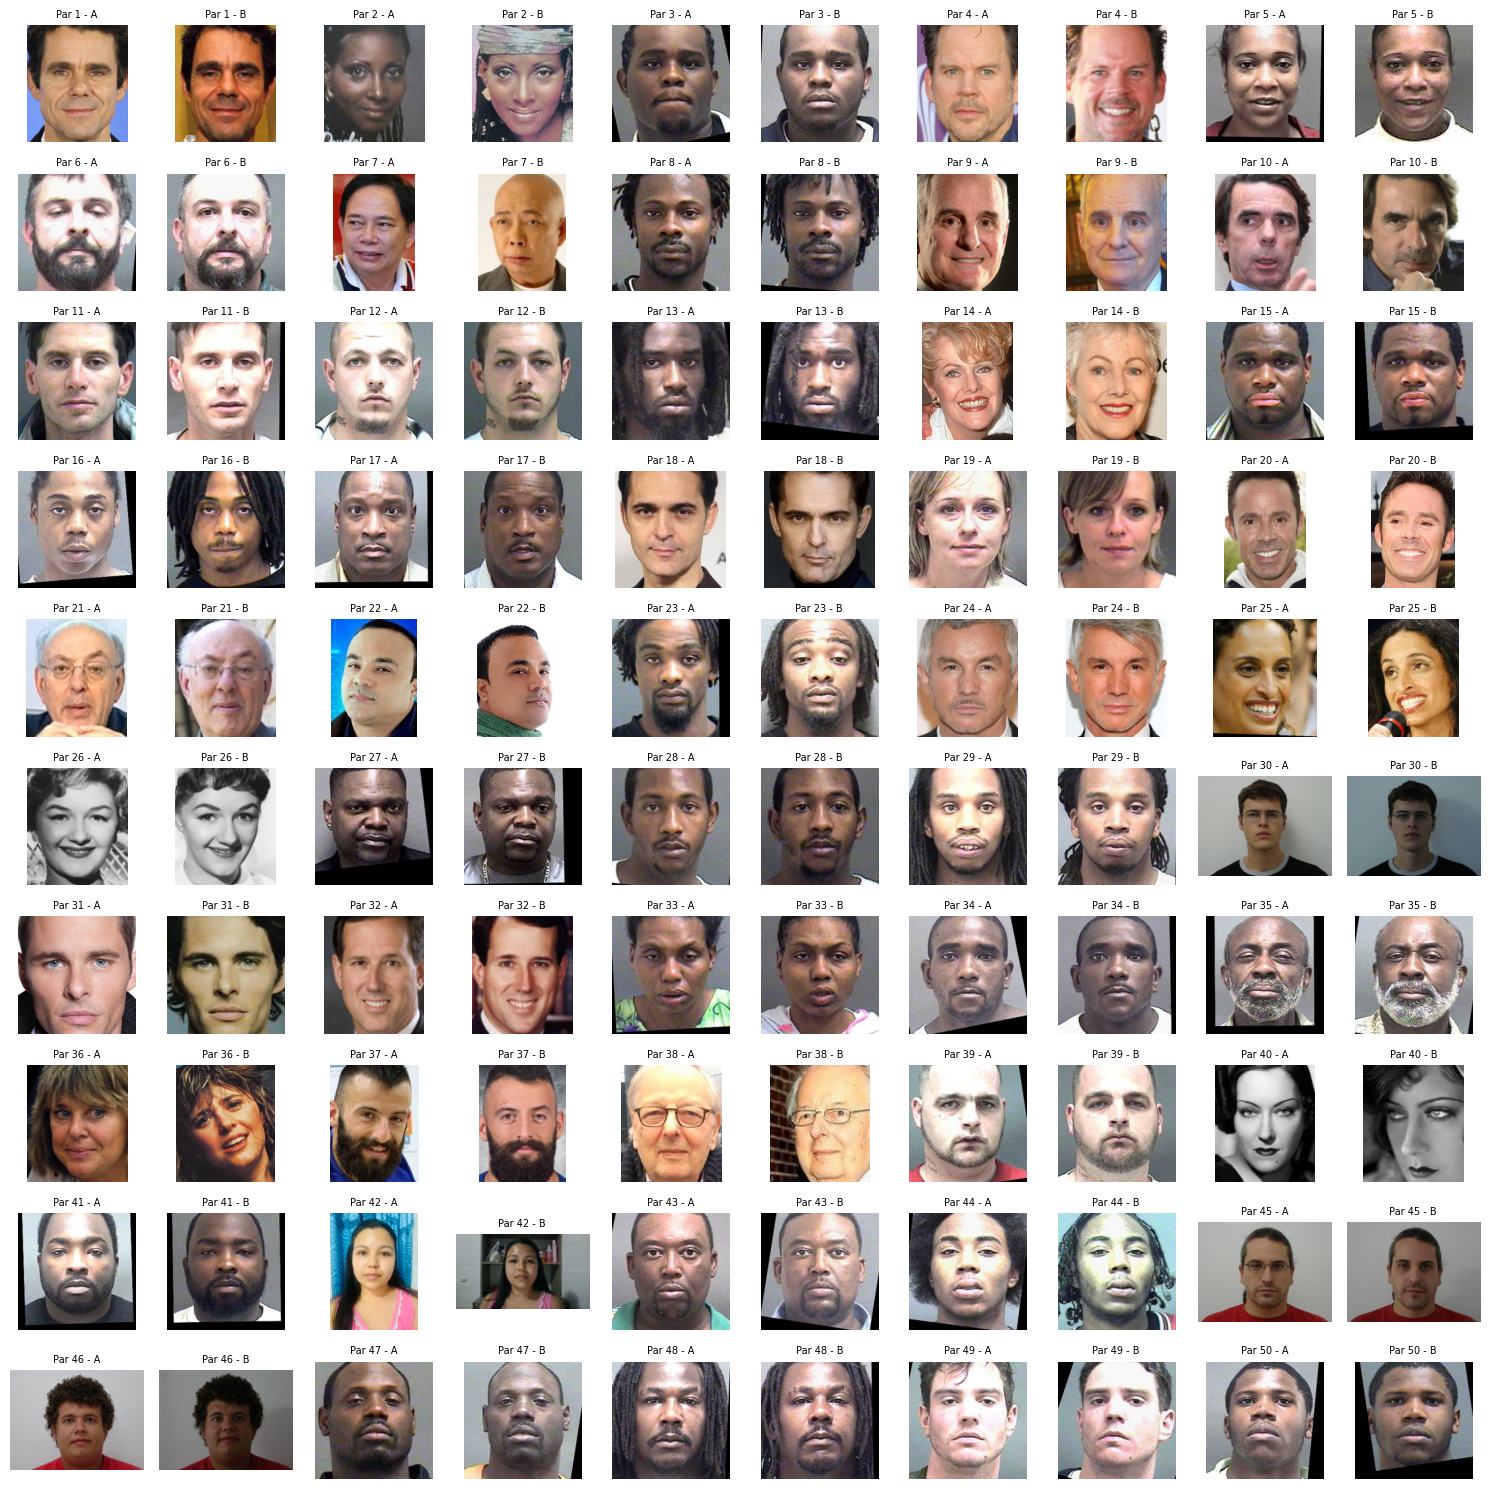

In [55]:
# 2. PLOTAGEM E SALVAMENTO
plotar_e_salvar_pares(
    selected_paths=selected_paths, 
    num_pairs=num_pairs,
    pairs_per_row=5,
    save_path='Avaliacao-FFC-10k/imagens-ffc-10k.png' # Ou use None para não salvar
)